In [3]:
import numpy as np 
import pandas as pd 
import re 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.preprocessing import StandardScaler, LabelEncoder 
from sklearn.model_selection import GroupShuffleSplit
from sklearn.decomposition import PCA 
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline 

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']   = 10


# 1. ĐỌC DỮ LIỆU ĐẦU VÀO


In [4]:
df = pd.read_csv('D:\Việt Anh\\MachineLearning\\ml_project_final\\data\\data\\train.csv', low_memory = False)
print(df.shape)
df.head(5)

(100000, 28)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


# 2. XỬ LÝ DỮ LIỆU RÁC VÀ MISSING VALUES

## 2.1. Xóa cột không cần thiết & làm sạch numeric

In [5]:
df.drop(columns = ['ID', 'Name', "SSN"], inplace = True, errors = 'ignore')


In [6]:
def clean_numeric(series):
    """Xóa ký tự lỗi, chuyển về float, đặt âm/vô lý thành NaN."""
    s = series.astype(str).str.replace(r"[^0-9.\-]", "", regex=True)
    s = pd.to_numeric(s, errors="coerce")
    return s

NUMERIC_COLS = [
    "Age", "Annual_Income", "Monthly_Inhand_Salary", "Num_Bank_Accounts",
    "Num_Credit_Card", "Interest_Rate", "Num_of_Loan",
    "Delay_from_due_date", "Num_of_Delayed_Payment", "Changed_Credit_Limit",
    "Num_Credit_Inquiries", "Outstanding_Debt", "Credit_Utilization_Ratio",
    "Total_EMI_per_month", "Amount_invested_monthly", "Monthly_Balance",
]

for col in NUMERIC_COLS:
    if col in df.columns:
        df[col] = clean_numeric(df[col])

# Các giá trị âm vô lý → NaN
NON_NEGATIVE = [
    "Age", "Annual_Income", "Monthly_Inhand_Salary", "Num_Bank_Accounts",
    "Num_Credit_Card", "Num_of_Loan", "Num_of_Delayed_Payment",
    "Num_Credit_Inquiries", "Outstanding_Debt", "Total_EMI_per_month",
    "Amount_invested_monthly",
]
for col in NON_NEGATIVE:
    if col in df.columns:
        df.loc[df[col] < 0, col] = np.nan

In [7]:
VALID_VALUES = {
    "Credit_Mix": {"Bad", "Standard", "Good"},

    "Occupation": {
        "Scientist", "Teacher", "Engineer", "Entrepreneur",
        "Developer", "Lawyer", "Media_Manager", "Doctor",
        "Journalist", "Manager", "Accountant", "Musician",
        "Mechanic", "Writer", "Architect",
    },

    "Payment_Behaviour" : {
        "High_spent_Small_value_payments",
        "Low_spent_Large_value_payments",
        "Low_spent_Medium_value_payments",
        "Low_spent_Small_value_payments",
        "High_spent_Large_value_payments",
        "High_spent_Medium_value_payments",
    },
}

print("Số NaN mới sinh ra sau khi lọc:")
for col, valid_set in VALID_VALUES.items():
    if col not in df.columns:
        continue

    before_nan   = df[col].isna().sum()
    before_dirty = (~df[col].isin(valid_set) & df[col].notna()).sum()

    # Thay giá trị không hợp lệ → NaN
    df[col] = df[col].where(df[col].isin(valid_set), other=np.nan)

    after_nan = df[col].isna().sum()
    print(f"  {col:<16} | giá trị lỗi: {before_dirty:>5} "
          f"| NaN trước: {before_nan:>5} → NaN sau: {after_nan:>5}")

Số NaN mới sinh ra sau khi lọc:
  Credit_Mix       | giá trị lỗi: 20195 | NaN trước:     0 → NaN sau: 20195
  Occupation       | giá trị lỗi:  7062 | NaN trước:     0 → NaN sau:  7062
  Payment_Behaviour | giá trị lỗi:  7600 | NaN trước:     0 → NaN sau:  7600


In [8]:
missing_value = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_data = pd.DataFrame({'Missing Values': missing_value, 'Percentage (%)': missing_percent})
print(missing_data[missing_data['Missing Values']> 0])

print(f"\n So luong dong trung lap: {df.duplicated().sum()}")

                         Missing Values  Percentage (%)
Age                                 886           0.886
Occupation                         7062           7.062
Monthly_Inhand_Salary             15002          15.002
Num_Bank_Accounts                    21           0.021
Num_of_Loan                        3876           3.876
Type_of_Loan                      11408          11.408
Num_of_Delayed_Payment             7646           7.646
Changed_Credit_Limit               2091           2.091
Num_Credit_Inquiries               1965           1.965
Credit_Mix                        20195          20.195
Credit_History_Age                 9030           9.030
Amount_invested_monthly            4479           4.479
Payment_Behaviour                  7600           7.600
Monthly_Balance                    1200           1.200

 So luong dong trung lap: 0


In [9]:
def parse_credit_history_age(val):
    """'22 Years and 3 Months' → 267 (tháng)"""
    if pd.isna(val):
        return np.nan
    val = str(val)
    years  = re.search(r"(\d+)\s*Year",  val, re.IGNORECASE)
    months = re.search(r"(\d+)\s*Month", val, re.IGNORECASE)
    y = int(years.group(1))  if years  else 0
    m = int(months.group(1)) if months else 0
    return y * 12 + m

df["Credit_History_Age"] = df["Credit_History_Age"].apply(parse_credit_history_age)

In [10]:
def iqr_clip(series, factor=3.0):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return series.clip(lower=Q1 - factor * IQR, upper=Q3 + factor * IQR)

for col in NUMERIC_COLS:
    if col in df.columns:
        df[col] = iqr_clip(df[col])

## 2.2. Imputation

**Chiến lược:**
- Numeric: median theo Customer_ID (vì mỗi customer có 8 tháng data, median robust hơn mean)
- Categorical: mode theo Customer_ID + global mode fallback cho customer thiếu 8/8

In [11]:
import pandas as pd
import numpy as np

# 0. Tiền xử lý Type_of_Loan trước (cột đặc biệt - multi-value)
# Type_of_Loan chứa nhiều loại loan trong 1 cell, ví dụ:
# "Auto Loan, Credit-Builder Loan, Personal Loan"
# → cần xử lý riêng, không impute thô như categorical thông thường

def get_loan_mode_per_customer(df):
    """
    Với mỗi customer, tìm chuỗi Type_of_Loan xuất hiện nhiều nhất
    trong 8 tháng (trong số các tháng không bị NaN).
    """
    def mode_or_nan(x):
        valid = x.dropna()
        if len(valid) == 0:
            return np.nan
        return valid.mode()[0]

    return df.groupby("Customer_ID")["Type_of_Loan"].transform(mode_or_nan)



# 1. Imputation cho các cột số
NUMERIC_IMPUTE_COLS = [
    "Age",
    "Num_Bank_Accounts",
    "Num_of_Loan",
    "Changed_Credit_Limit",
    "Monthly_Inhand_Salary",
    "Num_of_Delayed_Payment",
    "Num_Credit_Inquiries",
    "Credit_History_Age",
    "Amount_invested_monthly",
    "Monthly_Balance",
]

def impute_numeric_by_customer(df, cols):
    """
    Điền NaN bằng median của chính Customer_ID đó.
    Không cần global fallback vì không có customer nào thiếu 8/8.
    """
    df = df.copy()
    for col in cols:
        if col not in df.columns:
            continue

        before = df[col].isna().sum()

        df[col] = df.groupby("Customer_ID")[col].transform(
            lambda x: x.fillna(x.median())
        )

        after = df[col].isna().sum()
        print(f"  {col:<28} | filled: {before - after:>5} | còn lại: {after:>4}")

    return df


# 2. Imputation cho Type_of_Loan (categorical + global fallback)
def impute_type_of_loan(df):
    """
    Bước 1: Điền bằng mode của chính customer đó (các tháng có giá trị).
    Bước 2: 1426 customers thiếu 8/8 → điền bằng global mode.
    """
    df = df.copy()
    before = df["Type_of_Loan"].isna().sum()

    # Bước 1: customer-level mode
    df["Type_of_Loan"] = get_loan_mode_per_customer(df)

    # Bước 2: global fallback cho 1426 customers thiếu 8/8
    global_mode = df["Type_of_Loan"].mode()[0]
    remaining   = df["Type_of_Loan"].isna().sum()
    df["Type_of_Loan"] = df["Type_of_Loan"].fillna(global_mode)

    filled_customer = before - remaining
    filled_global   = remaining

    print(f"  {'Type_of_Loan':<28} | "
          f"customer-fill: {filled_customer:>5} | "
          f"global-fill: {filled_global:>5} (global_mode='{global_mode}')")

    return df


# 3. Chạy toàn bộ pipeline imputation
def run_imputation(df):
    print(">>> BẮT ĐẦU IMPUTATION\n")

    print("[1] Numeric — customer median:")
    df = impute_numeric_by_customer(df, NUMERIC_IMPUTE_COLS)

    print("\n[2] Categorical — customer mode + global fallback:")
    df = impute_type_of_loan(df)

    # Kiểm tra tổng kết
    remaining_missing = df[NUMERIC_IMPUTE_COLS + ["Type_of_Loan"]].isna().sum()
    remaining_missing = remaining_missing[remaining_missing > 0]

    print("\n>>> KẾT QUẢ SAU IMPUTATION:")
    if len(remaining_missing) == 0:
        print("  không còn missing value trong các cột đã xử lý.")
    else:
        print(remaining_missing)

    return df

df = run_imputation(df)

>>> BẮT ĐẦU IMPUTATION

[1] Numeric — customer median:
  Age                          | filled:   886 | còn lại:    0
  Num_Bank_Accounts            | filled:    21 | còn lại:    0
  Num_of_Loan                  | filled:  3876 | còn lại:    0
  Changed_Credit_Limit         | filled:  2091 | còn lại:    0
  Monthly_Inhand_Salary        | filled: 15002 | còn lại:    0
  Num_of_Delayed_Payment       | filled:  7646 | còn lại:    0
  Num_Credit_Inquiries         | filled:  1965 | còn lại:    0
  Credit_History_Age           | filled:  9030 | còn lại:    0
  Amount_invested_monthly      | filled:  4479 | còn lại:    0
  Monthly_Balance              | filled:  1200 | còn lại:    0

[2] Categorical — customer mode + global fallback:
  Type_of_Loan                 | customer-fill:     0 | global-fill: 11408 (global_mode='Not Specified')

>>> KẾT QUẢ SAU IMPUTATION:
  không còn missing value trong các cột đã xử lý.


In [12]:
def impute_categorical_by_customer(df, cols):
    """
    Bước 1: mode của chính Customer_ID đó.
    Bước 2: global mode fallback nếu customer thiếu 8/8.
    """
    df = df.copy()
    for col in cols:
        if col not in df.columns:
            continue

        before = df[col].isna().sum()

        # Bước 1: customer-level mode
        def fill_mode(x):
            valid = x.dropna()
            if len(valid) == 0:
                return x           # toàn NaN → để fallback xử lý
            return x.fillna(valid.mode()[0])

        df[col] = df.groupby("Customer_ID")[col].transform(fill_mode)

        # Bước 2: global mode fallback
        after_step1   = df[col].isna().sum()
        global_mode   = df[col].mode()[0]
        df[col]       = df[col].fillna(global_mode)
        after_step2   = df[col].isna().sum()

        cust_filled   = before - after_step1
        global_filled = after_step1 - after_step2

        note = f" | ⚠ global fallback: {global_filled} (mode='{global_mode}')" \
               if global_filled > 0 else ""
        print(f"  {col:<16} filled: {cust_filled:>5} (customer){note} "
              f"| còn lại: {after_step2}")

    return df


print("Imputing Occupation & Credit_Mix:")
df = impute_categorical_by_customer(df, list(VALID_VALUES.keys()))

Imputing Occupation & Credit_Mix:
  Credit_Mix       filled: 20195 (customer) | còn lại: 0
  Occupation       filled:  7062 (customer) | còn lại: 0
  Payment_Behaviour filled:  7600 (customer) | còn lại: 0


In [13]:
missing_value = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_data = pd.DataFrame({'Missing Values': missing_value, 'Percentage (%)': missing_percent})
print(missing_data[missing_data['Missing Values']> 0])

print(f"\n So luong dong trung lap: {df.duplicated().sum()}")

Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []

 So luong dong trung lap: 0


# 3. FEATURE ENCODING

In [14]:
df_enc = df.drop(columns=['Month'], errors='ignore').copy()
print(df_enc.shape)

(100000, 24)


In [15]:
#encode credit_score 
credit_score_map = {'Poor': 0, 'Standard': 1, 'Good': 2} 
df_enc['Credit_Score'] = df_enc['Credit_Score'].map(credit_score_map) 
print("Phan phoi credit_score")
print(df_enc["Credit_Score"].value_counts().sort_index().rename({0:'Poor', 1:'Standard', 2:'Good'}))

Phan phoi credit_score
Credit_Score
Poor        28998
Standard    53174
Good        17828
Name: count, dtype: int64


In [16]:
#encode credit_mix 
credit_mix_map = {'Bad': 0, 'Standard': 1, 'Good': 2}
df_enc['Credit_Mix'] = df_enc['Credit_Mix'].map(credit_mix_map)

In [17]:
# Encode Payment_of_Min_Amount (Ordinal)
pom_map = {'No': 0, 'NM': 1, 'Yes': 2}
df_enc['Payment_of_Min_Amount'] = df_enc['Payment_of_Min_Amount'].map(pom_map)

unmapped = df_enc['Payment_of_Min_Amount'].isna().sum()
print(f"NaN sau map: {unmapped}")

NaN sau map: 0


Trước khi encode Payment_Behaviour thì ta cần hiểu đặc tính của cột này như sau : 
- Cấu trúc: "{Spend_Level}_spent_{Value_Level}_value_payments"
  Ví dụ:    "High_spent_Small_value_payments"
=> tách thay vì OHE : 
- vì OHE tạo ra 6 cột nhị phân, mất đi cấu trúc 2 chiều độc lập; trong khi tách thì tạo ra 2 cột ordinal, giảm từ 6 xuống 2 và linear model có thể học coefficient riêng cho từng chiều 

=>  
 Spend_Level:  Low=0, High=1
 Value_Level:  Small=0, Medium=1, Large=2

In [18]:
print(df_enc.shape)

(100000, 24)


In [19]:
df_enc['Spend_Level'] = (
    df_enc['Payment_Behaviour']
    .str.extract(r'^(High|Low)_spent', expand=False)
    .map({'Low': 0, 'High': 1})
)
df_enc['Value_Level'] = (
    df_enc['Payment_Behaviour']
    .str.extract(r'(Small|Medium|Large)_value', expand=False)
    .map({'Small': 0, 'Medium': 1, 'Large': 2})
)

df_enc.drop(columns=['Payment_Behaviour'], inplace=True)
print("NaN check:", df_enc[['Spend_Level', 'Value_Level']].isna().sum().to_dict())


NaN check: {'Spend_Level': 0, 'Value_Level': 0}


Mỗi cell chứa nhiều loại loan: "Auto Loan, Personal Loan, and Student Loan"
Multi-hot = một cột binary cho mỗi loại loan.

In [20]:
def multihot_type_of_loan(df, col='Type_of_Loan'):
    cleaned = df[col].str.replace(r'\band\b', '', regex=True)
    cleaned = cleaned.str.replace(r'\s+', ' ', regex=True).str.strip()
    loan_lists = cleaned.str.split(r'\s*,\s*')

    all_types = set()
    loan_lists.dropna().apply(
        lambda x: all_types.update([t.strip() for t in x if t.strip()])
    )
    all_types = sorted(all_types)

    print(f"Các loại loan ({len(all_types)}):")
    for t in all_types:
        cnt = loan_lists.apply(lambda x: t in x if isinstance(x, list) else False).sum()
        print(f"  {t:<35} | n={cnt}")

    for loan_type in all_types:
        col_name = 'Loan_' + loan_type.replace(' ', '_').replace('-', '_')
        df[col_name] = loan_lists.apply(
            lambda x: 1 if (isinstance(x, list) and loan_type in x) else 0
        )

    df.drop(columns=[col], inplace=True)
    return df

df_enc = multihot_type_of_loan(df_enc)
loan_cols = [c for c in df_enc.columns if c.startswith('Loan_')]
print(f"\nSố cột Loan_: {len(loan_cols)}")

Các loại loan (9):
  Auto Loan                           | n=30560
  Credit-Builder Loan                 | n=31728
  Debt Consolidation Loan             | n=31040
  Home Equity Loan                    | n=31400
  Mortgage Loan                       | n=31360
  Not Specified                       | n=43088
  Payday Loan                         | n=31944
  Personal Loan                       | n=31104
  Student Loan                        | n=31040

Số cột Loan_: 9


Occupation là NOMINAL (không có thứ tự) với ~16 giá trị.
OHE được dùng THỐNG NHẤT cho tất cả model trong guide này vì:
 - Naive Bayes, LR, MLP, KNN, SVM đều là distance/probability-based  
 - Label Encoding tạo thứ tự giả tạo gây hại cho những model này
 - drop_first=True: loại 1 cột → tránh dummy variable trap (multicollinearity hoàn hảo)    
 -đặc biệt quan trọng với Logistic Regression

In [21]:
occ_dummies = pd.get_dummies(df_enc['Occupation'], prefix='Occ', drop_first=True)
df_enc = pd.concat([df_enc.drop(columns=['Occupation']), occ_dummies], axis=1)

occ_cols = [c for c in df_enc.columns if c.startswith('Occ_')]
print(f"Số cột Occ_ được tạo: {len(occ_cols)}")
print(f"Shape tổng sau toàn bộ encoding: {df_enc.shape}")

Số cột Occ_ được tạo: 14
Shape tổng sau toàn bộ encoding: (100000, 46)


In [22]:
df_enc.head(5)

,Customer_ID,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Occ_Entrepreneur,Occ_Journalist,Occ_Lawyer,Occ_Manager,Occ_Mechanic,Occ_Media_Manager,Occ_Musician,Occ_Scientist,Occ_Teacher,Occ_Writer
0,CUS_0xd40,23.0,19114.12,1824.843333,3.0,4.0,3,4.0,3,7.0,...,False,False,False,False,False,False,False,True,False,False
1,CUS_0xd40,23.0,19114.12,1824.843333,3.0,4.0,3,4.0,-1,6.5,...,False,False,False,False,False,False,False,True,False,False
2,CUS_0xd40,23.0,19114.12,1824.843333,3.0,4.0,3,4.0,3,7.0,...,False,False,False,False,False,False,False,True,False,False
3,CUS_0xd40,23.0,19114.12,1824.843333,3.0,4.0,3,4.0,5,4.0,...,False,False,False,False,False,False,False,True,False,False
4,CUS_0xd40,23.0,19114.12,1824.843333,3.0,4.0,3,4.0,6,6.5,...,False,False,False,False,False,False,False,True,False,False


# 4. EXPLORATORY DATA ANALYSIS (EDA)

## 4.1. Phân phối các cột ordinal/binary

Phân phối các cột oridinal/binary da encode

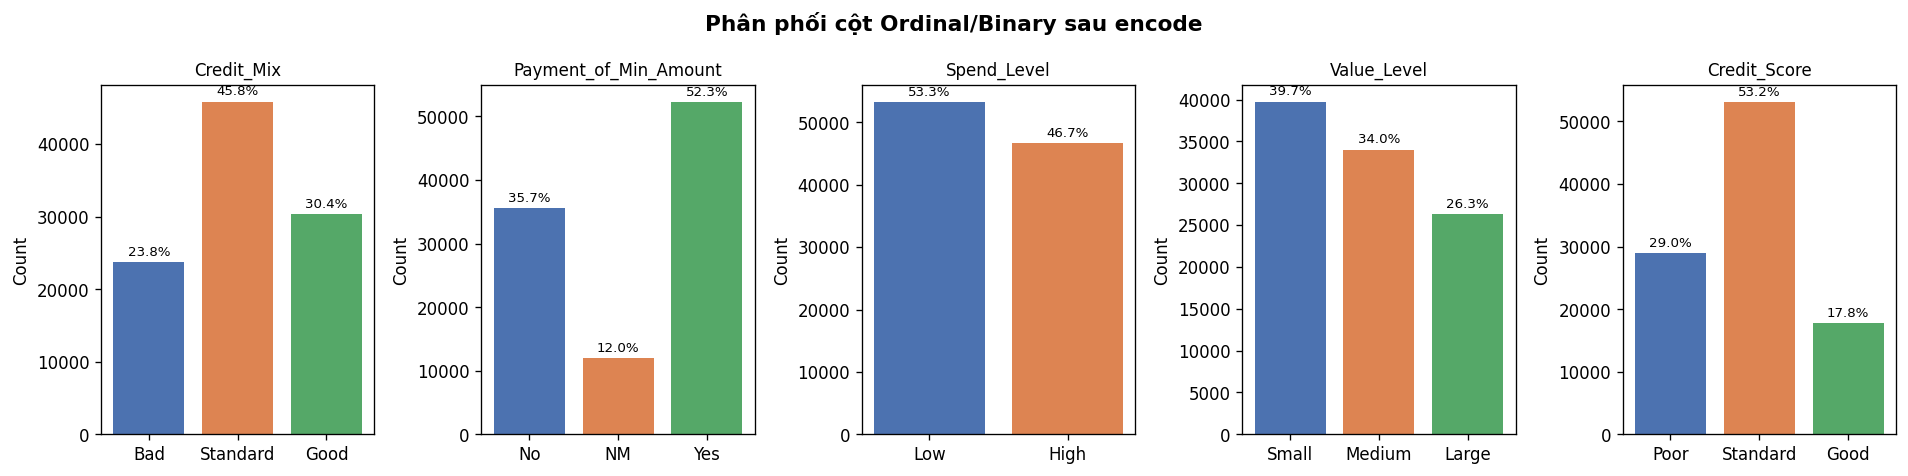

In [23]:
ordinal_cols = ['Credit_Mix', 'Payment_of_Min_Amount', 'Spend_Level', 'Value_Level', 'Credit_Score']

fig, axes = plt.subplots(1, len(ordinal_cols), figsize=(16, 4))
fig.suptitle('Phân phối cột Ordinal/Binary sau encode', fontsize=13, fontweight='bold')

label_maps = {
    'Credit_Mix':             {0:'Bad', 1:'Standard', 2:'Good'},
    'Payment_of_Min_Amount':  {0:'No',  1:'NM',       2:'Yes'},
    'Spend_Level':            {0:'Low', 1:'High'},
    'Value_Level':            {0:'Small', 1:'Medium',  2:'Large'},
    'Credit_Score':           {0:'Poor', 1:'Standard', 2:'Good'},
}

for ax, col in zip(axes, ordinal_cols):
    counts = df_enc[col].value_counts().sort_index()
    labels = [label_maps[col].get(k, str(k)) for k in counts.index]
    bars   = ax.bar(labels, counts.values, color=['#4C72B0','#DD8452','#55A868'][:len(counts)])
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Count')
    total = counts.sum()
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.005,
                f'{val/total:.1%}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('01_ordinal_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

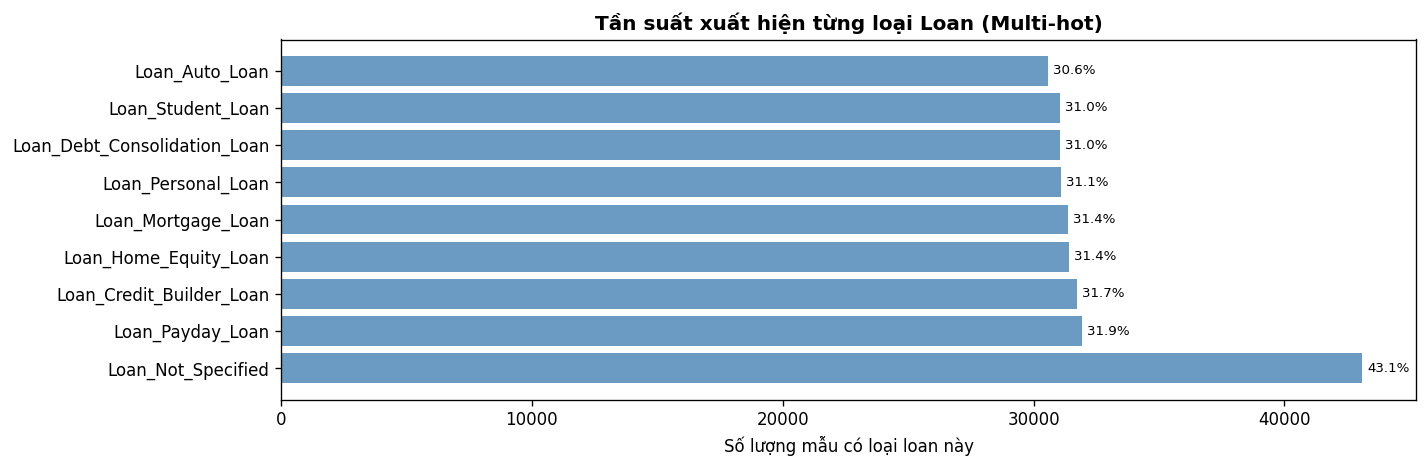

Tất cả loại loan đủ phổ biến.


In [24]:
fig, ax = plt.subplots(figsize=(12, 4))
loan_counts = df_enc[loan_cols].sum().sort_values(ascending=False)
bars = ax.barh(loan_counts.index, loan_counts.values, color='steelblue', alpha=0.8)
ax.set_xlabel('Số lượng mẫu có loại loan này')
ax.set_title('Tần suất xuất hiện từng loại Loan (Multi-hot)', fontweight='bold')

total = len(df_enc)
for bar, val in zip(bars, loan_counts.values):
    ax.text(val + total*0.002, bar.get_y() + bar.get_height()/2,
            f'{val/total:.1%}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('02_loan_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

LOAN_THRESHOLD = 0.01  
rare_loans = loan_counts[loan_counts / total < LOAN_THRESHOLD].index.tolist()
if rare_loans:
    print(f" Loại loan hiếm (< 1%), sẽ DROP: {rare_loans}")
    df_enc.drop(columns=rare_loans, inplace=True)
    loan_cols = [c for c in df_enc.columns if c.startswith('Loan_')]
    print(f"Còn lại {len(loan_cols)} cột Loan_")
else:
    print("Tất cả loại loan đủ phổ biến.")

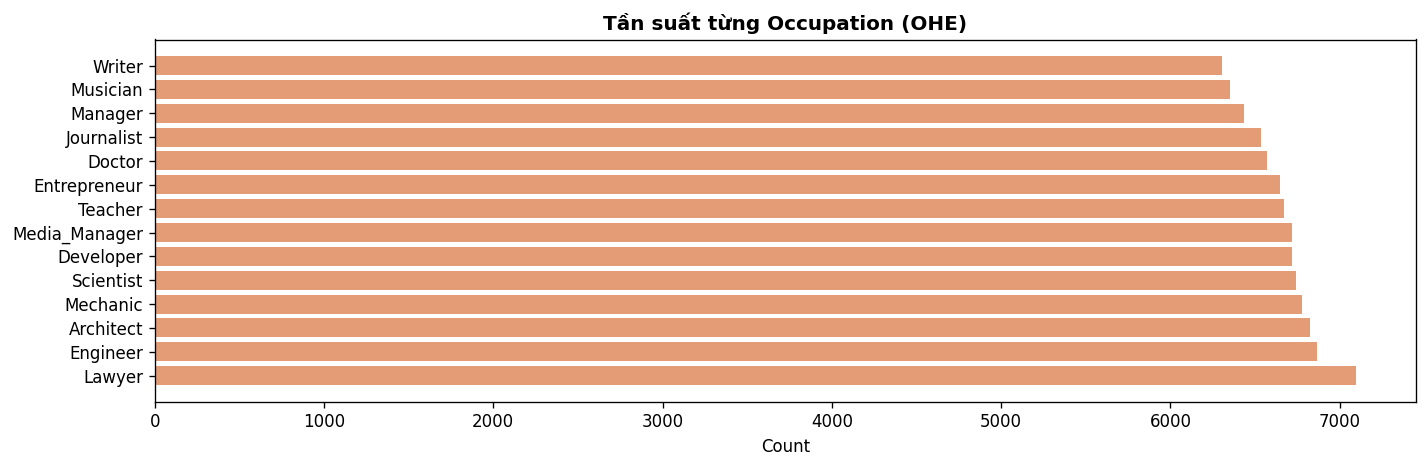

In [25]:
fig, ax = plt.subplots(figsize=(12, 4))
occ_counts = df_enc[occ_cols].sum().sort_values(ascending=False)
ax.barh(occ_counts.index.str.replace('Occ_', ''), occ_counts.values,
        color='#DD8452', alpha=0.8)
ax.set_xlabel('Count')
ax.set_title('Tần suất từng Occupation (OHE)', fontweight='bold')
plt.tight_layout()
plt.savefig('03_occupation_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

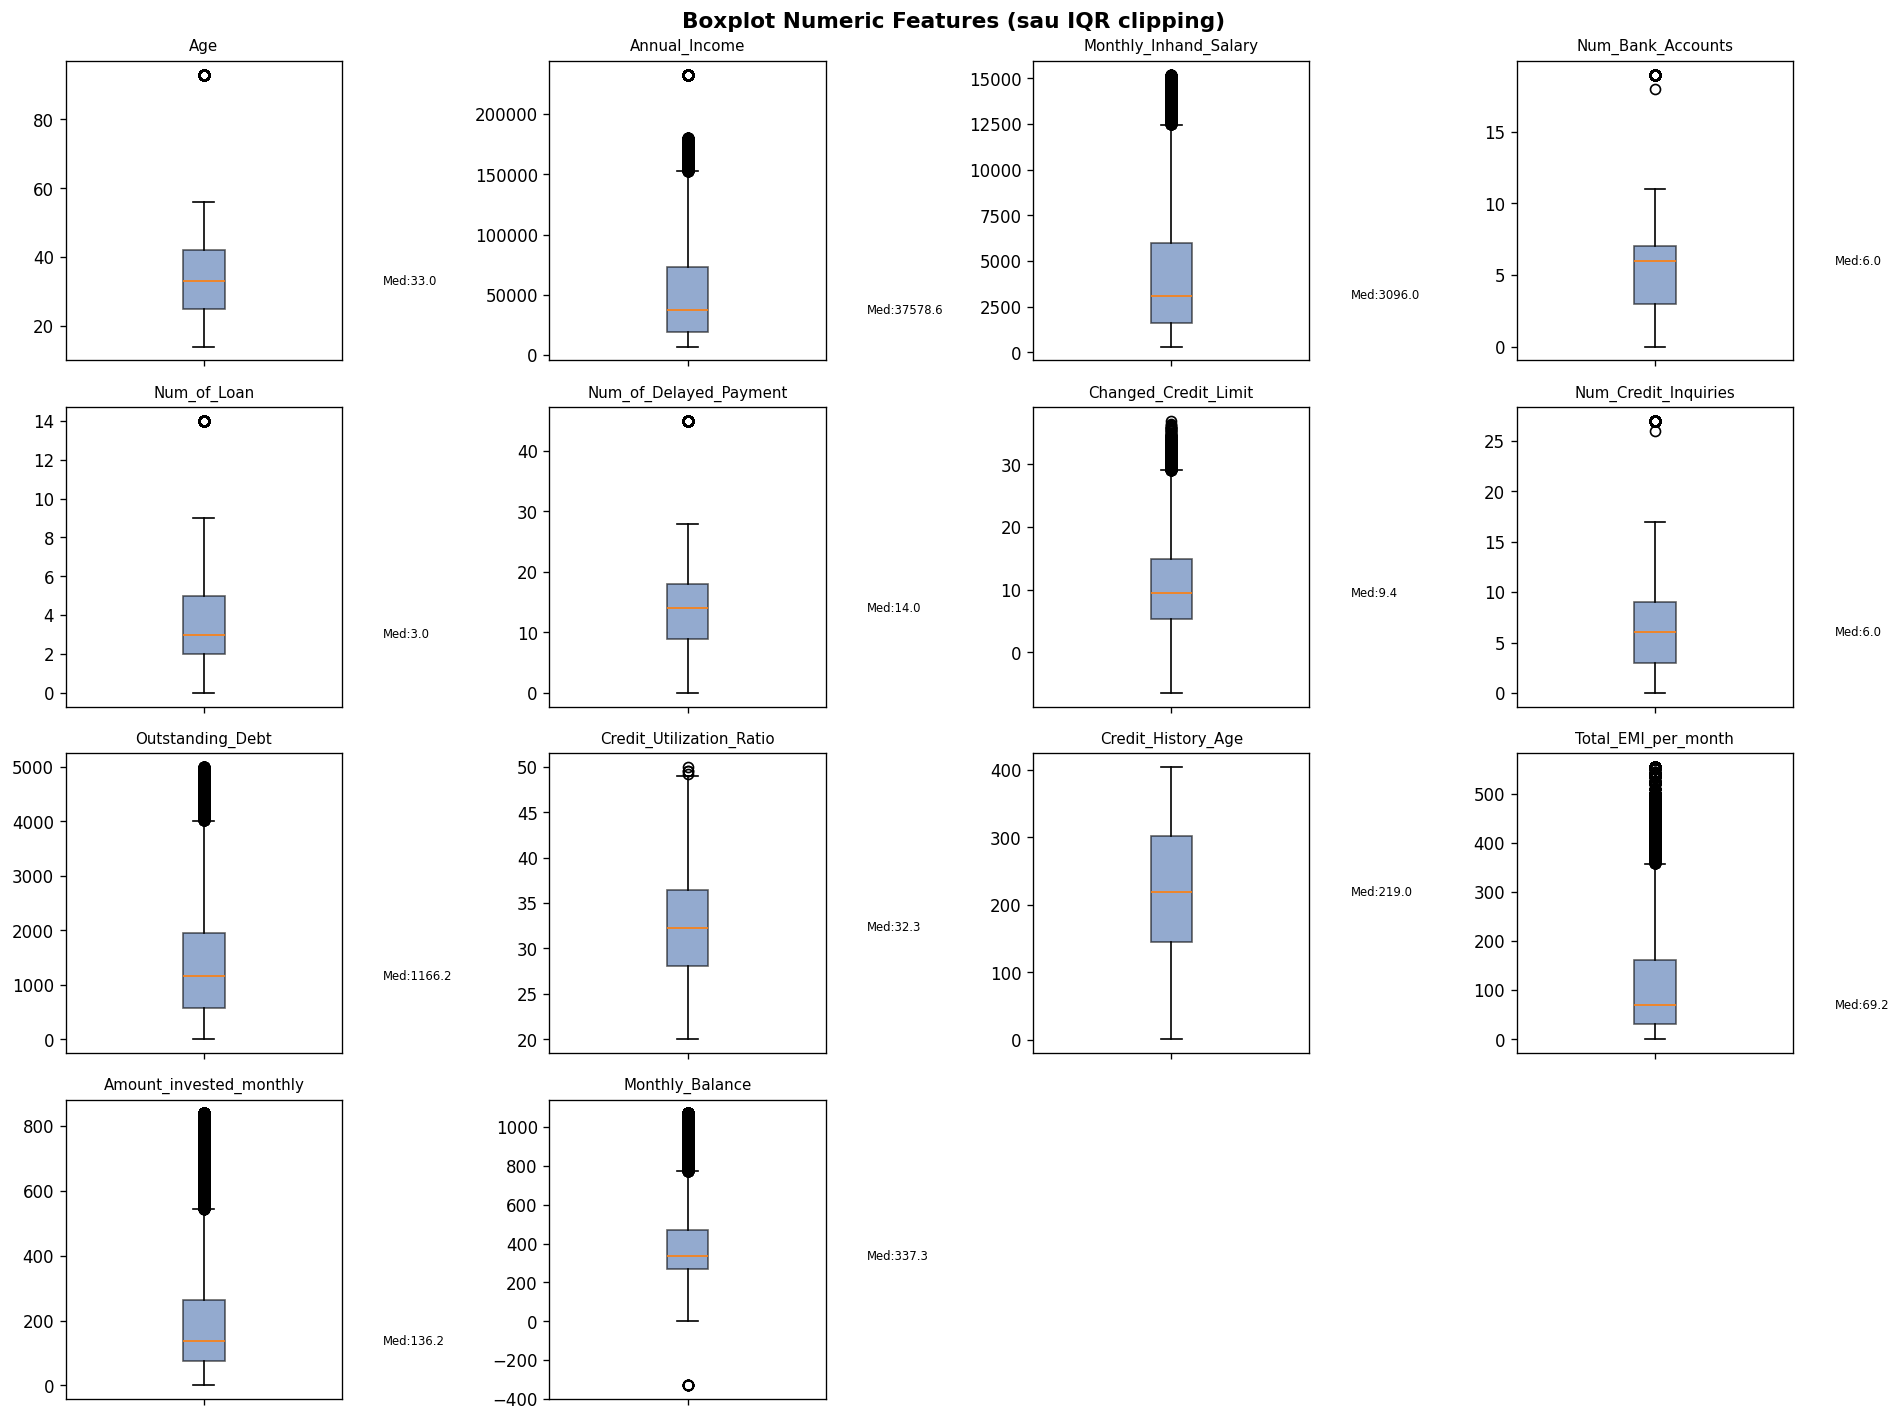

In [26]:
numeric_cols = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
    'Num_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
    'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
    'Credit_History_Age', 'Total_EMI_per_month',
    'Amount_invested_monthly', 'Monthly_Balance'
]
numeric_cols = [c for c in numeric_cols if c in df_enc.columns]

n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df_enc[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', alpha=0.6))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xticklabels([])

    # Annotate statistics
    q1, median, q3 = df_enc[col].quantile([0.25, 0.5, 0.75])
    axes[i].text(1.15, median, f'Med:{median:.1f}', fontsize=7,
                 va='center', transform=axes[i].get_yaxis_transform())

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Boxplot Numeric Features (sau IQR clipping)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('04_numeric_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.2. Nhận xét từ Boxplots

**1. Nhóm lệch phải nặng:**
- `Annual_Income`, `Monthly_Inhand_Salary`, `Total_EMI_per_month`, `Amount_invested_monthly`, `Outstanding_Debt`
- Phân phối lệch phải nặng ảnh hưởng đến Logistic Regression, MLP, Naive Bayes
- Làm cho PCA bị dominant bởi các feature có variance lớn
- **Giải pháp:** Dùng `log1p` transform

**2. Nhóm outliers đơn lẻ còn sót:**
- `Age`, `Num_Bank_Accounts`, `Num_of_Loan`
- Sau IQR clip vẫn còn 1 số giá trị extreme → chấp nhận được vì không quá nghiêm trọng

xử lý các lỗi vừa gặp phải 

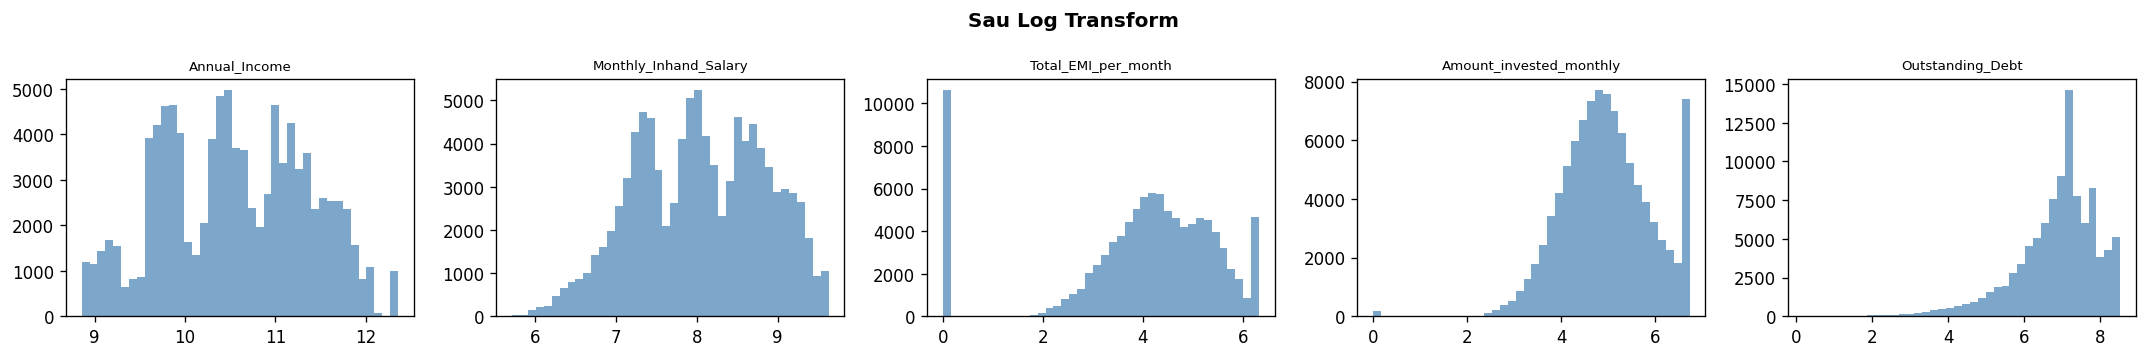

In [27]:
# log transform cho right-skewed 
log_cols = [
    'Annual_Income', 'Monthly_Inhand_Salary',
    'Total_EMI_per_month', 'Amount_invested_monthly',
    'Outstanding_Debt'
]

for col in log_cols:
    df_enc[col] = np.log1p(df_enc[col])

# Kiểm tra lại sau transform
fig, axes = plt.subplots(1, len(log_cols), figsize=(18, 3))
for ax, col in zip(axes, log_cols):
    ax.hist(df_enc[col].dropna(), bins=40, color='steelblue', alpha=0.7)
    ax.set_title(col, fontsize=8)
plt.suptitle('Sau Log Transform', fontweight='bold')
plt.tight_layout()
plt.show()

## 4.3. Nhận xét sau log transform

**Multi-modal distribution:**
- `annual_income`, `monthly_inhand_salary` đã đỡ lệch phải nhưng xuất hiện **nhiều đỉnh** (multi-modal)
- **Nguyên nhân:** dữ liệu thật sự có nhóm phân khúc thu nhập (low, mid, high income)
- **Ảnh hưởng:**
  - **Naive Bayes (GaussianNB):** vi phạm giả định Gaussian → performance kém 
  - **Logistic Regression:** non-linear boundary → linear LR khó bắt được
  - **SVM (RBF kernel):** xử lý tốt nhờ kernel non-linear
  - **MLP, KNN:** ảnh hưởng ít/không ảnh hưởng

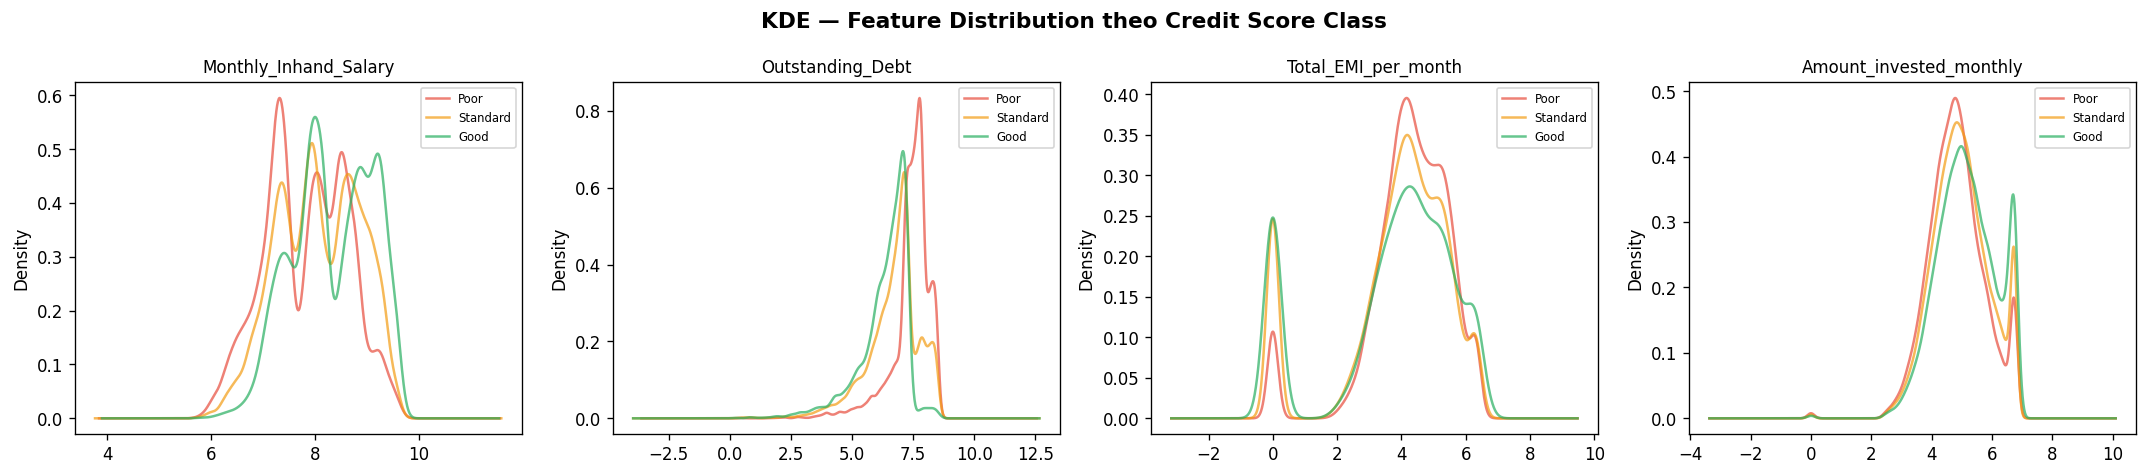

In [28]:
## 4.4. KDE Plot — Phân phối feature theo class (kiểm tra multi-modal)

multimodal_features = ['Monthly_Inhand_Salary', 'Outstanding_Debt', 
                       'Total_EMI_per_month', 'Amount_invested_monthly']
multimodal_features = [f for f in multimodal_features if f in df_enc.columns]

fig, axes = plt.subplots(1, len(multimodal_features), figsize=(18, 4))
colors = {0: '#e74c3c', 1: '#f39c12', 2: '#27ae60'}
labels = {0: 'Poor', 1: 'Standard', 2: 'Good'}

for ax, feat in zip(axes, multimodal_features):
    for cls in [0, 1, 2]:
        subset = df_enc[df_enc['Credit_Score'] == cls][feat].dropna()
        subset.plot.kde(ax=ax, color=colors[cls], label=labels[cls], alpha=0.7)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=7)
    ax.set_ylabel('Density')

fig.suptitle('KDE — Feature Distribution theo Credit Score Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('09_kde_multimodal.png', dpi=150, bbox_inches='tight')
plt.show()


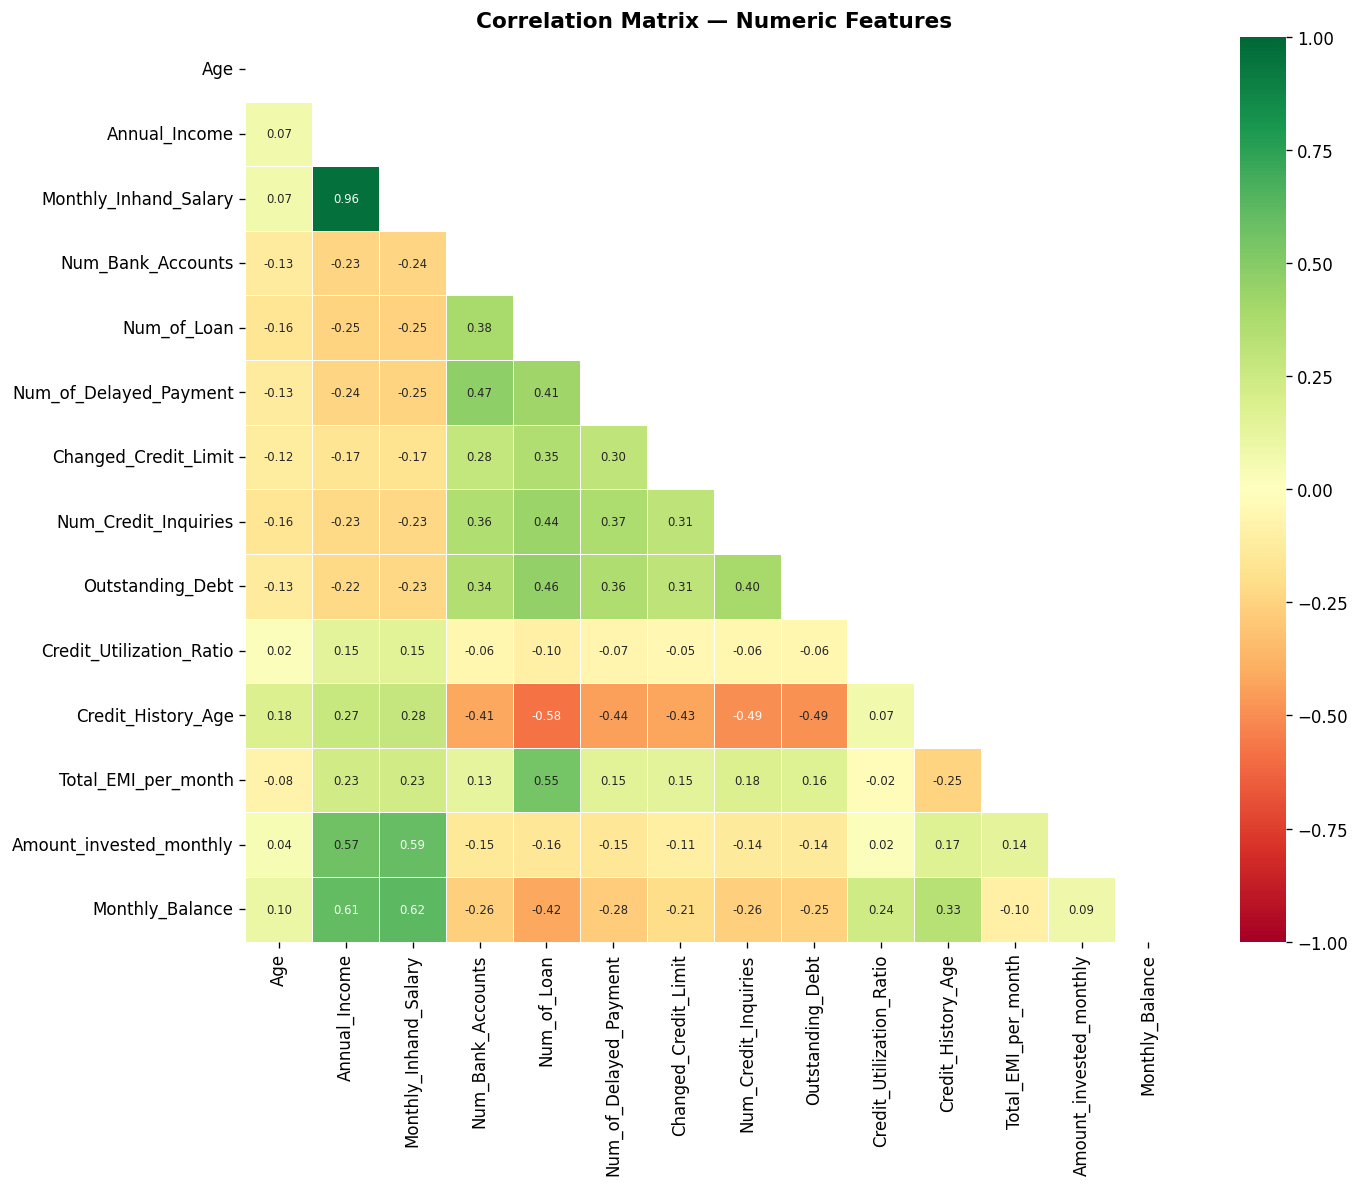

In [29]:
corr_matrix = df_enc[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlation Matrix — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Annual_Income và Monthly_Salary_Inhand tương quan cao => nên xóa 1 cột đi

In [30]:
df_enc.drop(columns=['Annual_Income'], inplace=True)

## 4.5. Kiểm tra Multicollinearity (VIF)

In [31]:
# Tính VIF cho các numeric features còn lại
numeric_for_vif = [c for c in df_enc.select_dtypes(include=[np.number]).columns 
                   if c != 'Credit_Score']

# Cần scale trước khi tính VIF
from sklearn.preprocessing import StandardScaler
scaler_vif = StandardScaler()
X_vif = pd.DataFrame(
    scaler_vif.fit_transform(df_enc[numeric_for_vif]),
    columns=numeric_for_vif
)

vif_data = pd.DataFrame({
    'Feature': numeric_for_vif,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(len(numeric_for_vif))]
}).sort_values('VIF', ascending=False)

print("=== Variance Inflation Factor ===")
print(vif_data.to_string(index=False))
print(f"\nFeatures với VIF > 10 (multicollinearity cao):")
print(vif_data[vif_data['VIF'] > 10].to_string(index=False))


=== Variance Inflation Factor ===
                     Feature      VIF
                 Num_of_Loan 5.631438
                  Credit_Mix 5.223167
       Monthly_Inhand_Salary 4.546038
     Amount_invested_monthly 2.708941
             Monthly_Balance 2.649008
       Payment_of_Min_Amount 2.351780
         Total_EMI_per_month 2.243701
          Credit_History_Age 2.112174
         Delay_from_due_date 2.029953
      Num_of_Delayed_Payment 1.929561
               Interest_Rate 1.702439
           Num_Bank_Accounts 1.650471
                 Spend_Level 1.583096
            Outstanding_Debt 1.568682
        Num_Credit_Inquiries 1.567876
            Loan_Payday_Loan 1.394231
    Loan_Credit_Builder_Loan 1.390895
          Loan_Mortgage_Loan 1.385702
           Loan_Student_Loan 1.378175
        Changed_Credit_Limit 1.376734
          Loan_Not_Specified 1.375814
       Loan_Home_Equity_Loan 1.369265
              Loan_Auto_Loan 1.365155
          Loan_Personal_Loan 1.361552
Loan_Debt_Consol

**Ghi chú VIF:**
- VIF > 10: multicollinearity nghiêm trọng → cân nhắc loại bỏ
- VIF > 5: multicollinearity vừa phải
- Đã loại `Annual_Income` (tương quan cao với `Monthly_Inhand_Salary`)
- PCA sẽ tự động xử lý multicollinearity còn lại

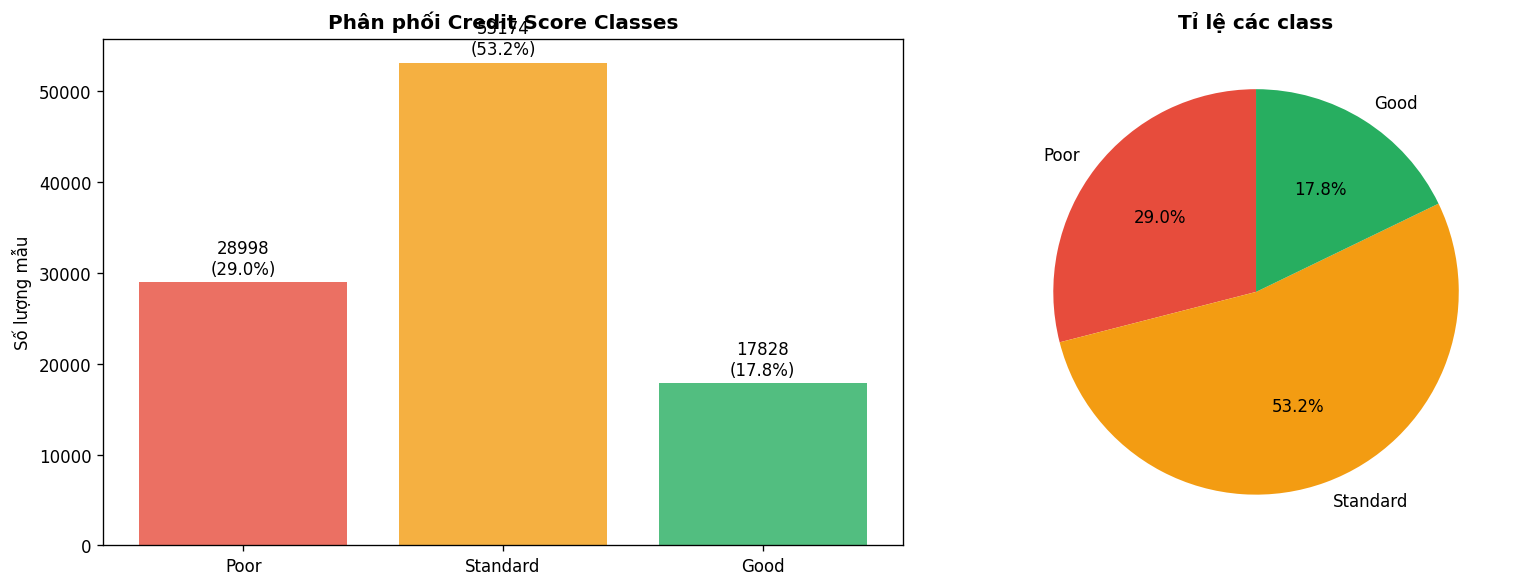


Tỉ lệ class: Poor=29.0%, Standard=53.2%, Good=17.8%
Imbalance ratio (max/min): 2.98x


In [32]:
# === PHÂN TÍCH CLASS IMBALANCE ===
class_counts = df_enc['Credit_Score'].value_counts().sort_index()
class_names = {0: 'Poor', 1: 'Standard', 2: 'Good'}
class_counts.index = class_counts.index.map(class_names)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
bars = axes[0].bar(class_counts.index, class_counts.values, 
                   color=['#e74c3c', '#f39c12', '#27ae60'], alpha=0.8)
for bar, val in zip(bars, class_counts.values):
    pct = val / class_counts.sum() * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
axes[0].set_title('Phân phối Credit Score Classes', fontweight='bold')
axes[0].set_ylabel('Số lượng mẫu')

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=['#e74c3c', '#f39c12', '#27ae60'], startangle=90)
axes[1].set_title('Tỉ lệ các class', fontweight='bold')

plt.tight_layout()
plt.savefig('10_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

# In tỉ lệ
print(f"\nTỉ lệ class: Poor={class_counts['Poor']/len(df_enc)*100:.1f}%, "
      f"Standard={class_counts['Standard']/len(df_enc)*100:.1f}%, "
      f"Good={class_counts['Good']/len(df_enc)*100:.1f}%")
print(f"Imbalance ratio (max/min): {class_counts.max()/class_counts.min():.2f}x")


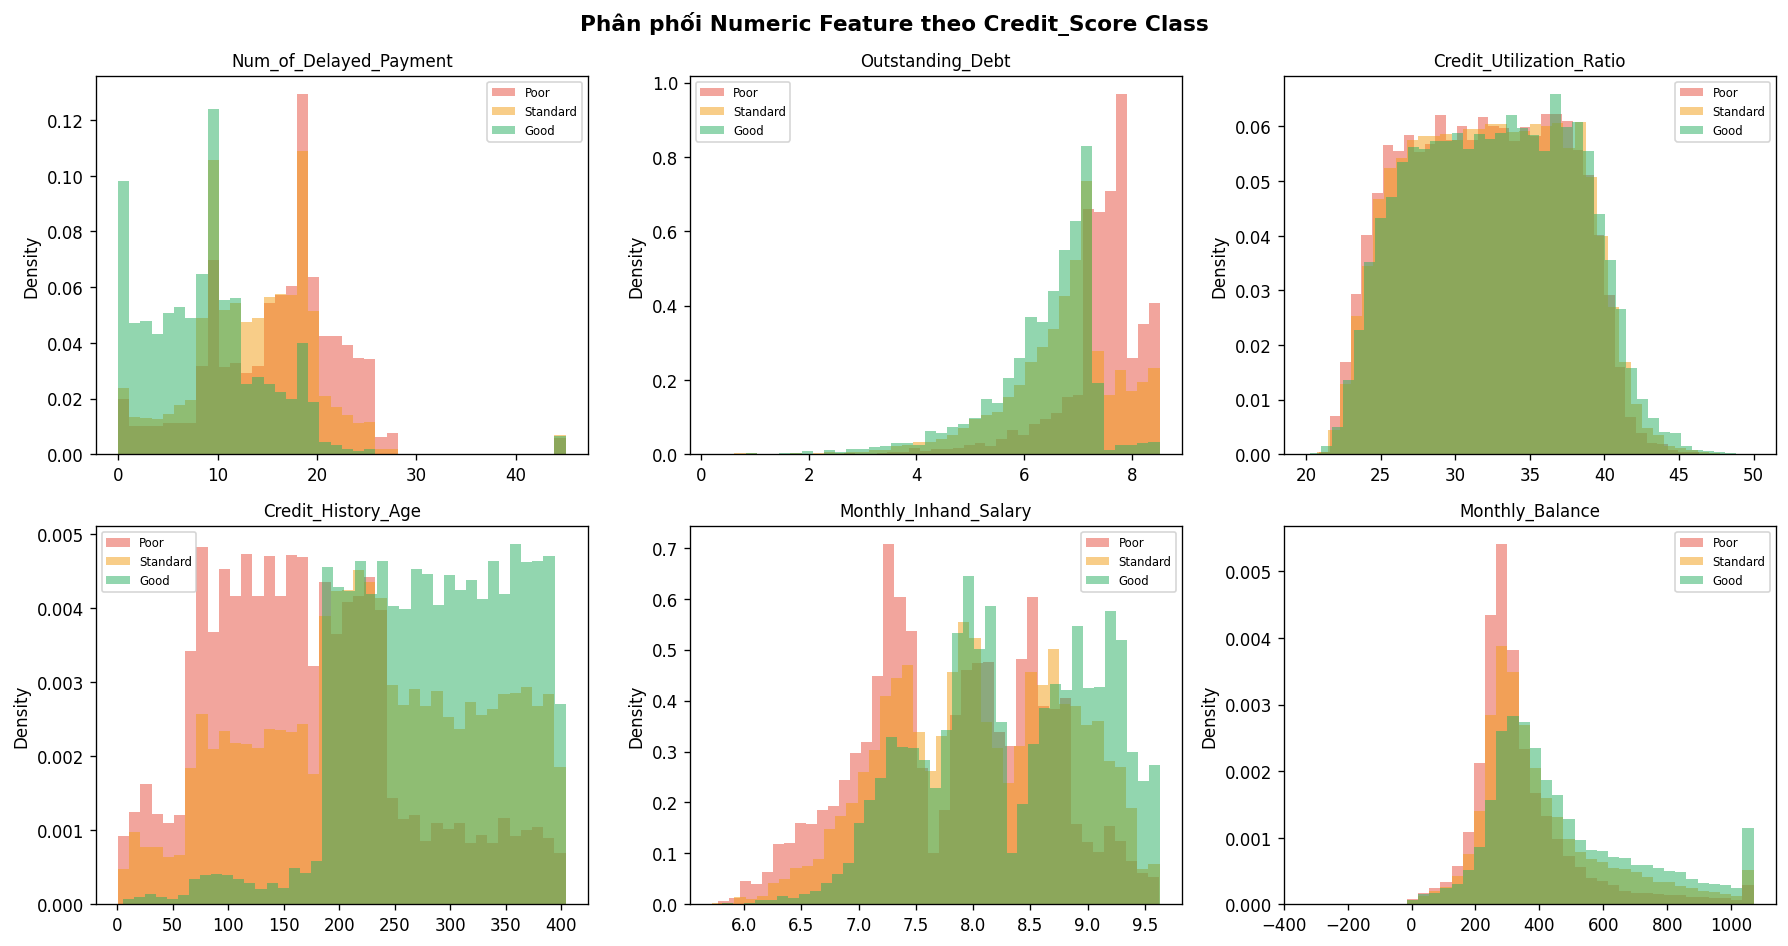

In [33]:
key_features = ['Num_of_Delayed_Payment', 'Outstanding_Debt',
                'Credit_Utilization_Ratio', 'Credit_History_Age',
                'Monthly_Inhand_Salary', 'Monthly_Balance']
key_features = [f for f in key_features if f in df_enc.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
colors = {0: '#e74c3c', 1: '#f39c12', 2: '#27ae60'}  # Poor=đỏ, Standard=vàng, Good=xanh

for i, feat in enumerate(key_features):
    for cls in [0, 1, 2]:
        subset = df_enc[df_enc['Credit_Score'] == cls][feat].dropna()
        axes[i].hist(subset, bins=40, alpha=0.5,
                     color=colors[cls],
                     label={0:'Poor', 1:'Standard', 2:'Good'}[cls],
                     density=True)
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=7)

fig.suptitle('Phân phối Numeric Feature theo Credit_Score Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('06_feature_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.7. Summary Statistics sau toàn bộ Preprocessing

In [34]:
# Verify: không còn NaN, kiểm tra range
print(f"Shape: {df_enc.shape}")
print(f"NaN tổng: {df_enc.isnull().sum().sum()}")
print(f"\n=== Numeric Features Summary ===")
numeric_summary = df_enc.select_dtypes(include=[np.number]).describe().T
numeric_summary = numeric_summary[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
print(numeric_summary.to_string())


Shape: (100000, 45)
NaN tổng: 0

=== Numeric Features Summary ===
                                 count        mean         std         min         25%         50%         75%          max
Age                           100000.0   34.449500   13.414694   14.000000   25.000000   33.000000   42.000000    93.000000
Monthly_Inhand_Salary         100000.0    8.045803    0.800134    5.719149    7.394961    8.038182    8.693268     9.629421
Num_Bank_Accounts             100000.0    5.547090    3.008061    0.000000    3.000000    6.000000    7.000000    19.000000
Num_Credit_Card               100000.0    5.770990    2.570827    0.000000    4.000000    5.000000    7.000000    16.000000
Interest_Rate                 100000.0   15.375070   10.444888    1.000000    8.000000   13.000000   20.000000    56.000000
Num_of_Loan                   100000.0    3.583110    2.543863    0.000000    2.000000    3.000000    5.000000    14.000000
Delay_from_due_date           100000.0   21.068780   14.860104   -

# 5. TRAIN/TEST SPLIT VÀ FEATURE SCALING

**Chiến lược split:**
- `GroupShuffleSplit` theo `Customer_ID` — đảm bảo tất cả các tháng của 1 customer nằm cùng 1 set
- Tránh **data leakage** (model nhìn thấy data tháng khác của cùng customer trong training)

In [35]:
feature_cols = [c for c in df_enc.columns if c not in ['Credit_Score', 'Customer_ID']]
X_all = df_enc[feature_cols] 
y_all = df_enc['Credit_Score'] 
groups = df_enc["Customer_ID"] 

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42) 
train_idx, test_idx = next(gss.split(X_all, y_all, groups))
X_train = X_all.iloc[train_idx].reset_index(drop=True)
X_test  = X_all.iloc[test_idx].reset_index(drop=True)
y_train = y_all.iloc[train_idx].reset_index(drop=True)
y_test  = y_all.iloc[test_idx].reset_index(drop=True)

In [36]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  

# 6. GIẢM CHIỀU DỮ LIỆU (DIMENSIONALITY REDUCTION)

## 6.1. PCA Analysis

**Chiến lược giảm chiều:**
- Sử dụng **PCA** cho TẤT CẢ models (tạo uncorrelated features, loại multicollinearity)
- 35 components (95% variance) cho NB, LR, MLP, SVM
- 20 components cho KNN (curse of dimensionality cần giảm mạnh hơn)
- **LDA** chỉ dùng cho **visualization** (vì chỉ giảm xuống 2D → mất quá nhiều info)

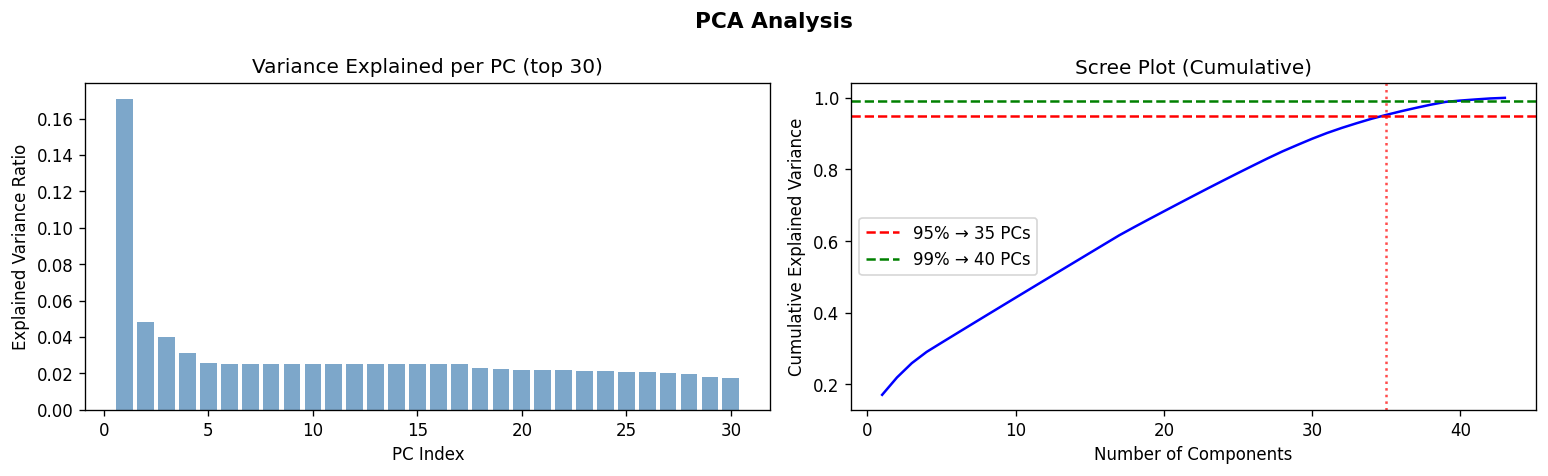

In [37]:
pca_analysis = PCA(random_state=42)
pca_analysis.fit(X_train_scaled)

cumvar = np.cumsum(pca_analysis.explained_variance_ratio_)
n_95   = np.argmax(cumvar >= 0.95) + 1
n_99   = np.argmax(cumvar >= 0.99) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, 31), pca_analysis.explained_variance_ratio_[:30],
            color='steelblue', alpha=0.7)
axes[0].set_xlabel('PC Index')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Variance Explained per PC (top 30)')

axes[1].plot(range(1, len(cumvar)+1), cumvar, 'b-', linewidth=1.5)
axes[1].axhline(0.95, color='r',  linestyle='--', label=f'95% → {n_95} PCs')
axes[1].axhline(0.99, color='g',  linestyle='--', label=f'99% → {n_99} PCs')
axes[1].axvline(n_95, color='r',  linestyle=':',  alpha=0.7)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Scree Plot (Cumulative)')
axes[1].legend()

fig.suptitle('PCA Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('07_pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
# === PCA LOADING ANALYSIS ===
# Phân tích features nào đóng góp nhiều nhất vào mỗi PC

feature_cols = [c for c in df_enc.columns if c not in ['Credit_Score', 'Customer_ID']]

# Lấy loading matrix (components)
pca_full = PCA(n_components=min(10, len(feature_cols)), random_state=42)
pca_full.fit(X_train_scaled)

loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f'PC{i+1}' for i in range(pca_full.n_components_)],
    index=feature_cols
)

# Top 5 features cho 5 PCs đầu tiên
print("=== Top 5 Features có loading lớn nhất cho mỗi PC ===\n")
for pc in ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']:
    top5 = loadings[pc].abs().nlargest(5)
    print(f"{pc} (explains {pca_full.explained_variance_ratio_[int(pc[2:])-1]*100:.1f}% variance):")
    for feat, val in top5.items():
        sign = '+' if loadings.loc[feat, pc] > 0 else '-'
        print(f"  {sign} {feat}: {loadings.loc[feat, pc]:.3f}")
    print()


=== Top 5 Features có loading lớn nhất cho mỗi PC ===

PC1 (explains 17.1% variance):
  + Credit_Mix: 0.325
  - Num_of_Loan: -0.293
  + Credit_History_Age: 0.279
  - Payment_of_Min_Amount: -0.272
  - Delay_from_due_date: -0.262

PC2 (explains 4.8% variance):
  + Monthly_Inhand_Salary: 0.493
  + Total_EMI_per_month: 0.476
  + Monthly_Balance: 0.329
  + Spend_Level: 0.325
  + Value_Level: 0.303

PC3 (explains 4.0% variance):
  + Spend_Level: 0.376
  + Monthly_Balance: 0.368
  - Total_EMI_per_month: -0.305
  + Loan_Not_Specified: 0.303
  + Value_Level: 0.302

PC4 (explains 3.1% variance):
  + Amount_invested_monthly: 0.686
  + Monthly_Inhand_Salary: 0.379
  - Spend_Level: -0.321
  + Loan_Not_Specified: 0.278
  - Value_Level: -0.195

PC5 (explains 2.6% variance):
  + Occ_Engineer: 0.515
  - Occ_Developer: -0.371
  - Occ_Entrepreneur: -0.311
  - Occ_Doctor: -0.273
  - Loan_Mortgage_Loan: -0.272



## 6.2. Kết luận PCA
- PCA: 35 components → 95% variance | 40 components → 99% variance
- Giảm từ 43 → 35 features (giữ 95% thông tin)
- **Sử dụng 35D cho NB, LR, MLP, SVM** và **20D cho KNN**

## 6.3. LDA Visualization
LDA chỉ dùng để **trực quan hóa** class separability (giảm xuống 2D).
**KHÔNG dùng** LDA output làm input cho models vì:
- Chỉ 2 components → mất quá nhiều information
- Class overlap nhiều → LDA projection kém
- Giả định equal covariance & Gaussian within-class bị vi phạm (multi-modal data)


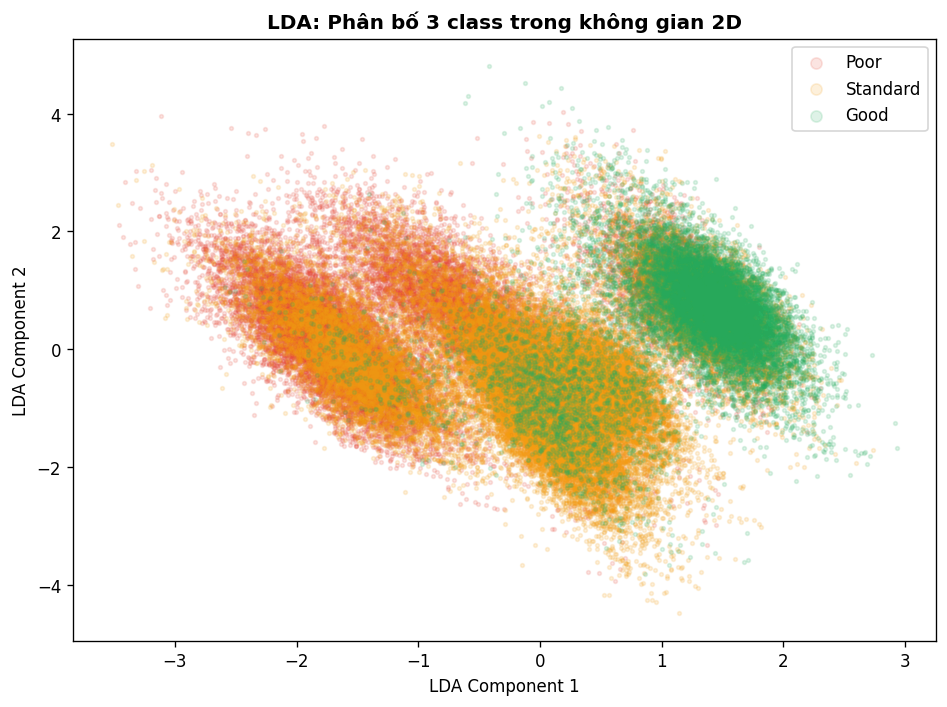

In [39]:
lda_analysis = LDA()
X_train_lda2 = lda_analysis.fit_transform(X_train_scaled, y_train)
X_test_lda2  = lda_analysis.transform(X_test_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
colors_map = {0: '#e74c3c', 1: '#f39c12', 2: '#27ae60'}
labels_map  = {0: 'Poor', 1: 'Standard', 2: 'Good'}

for cls in [0, 1, 2]:
    mask = y_train == cls
    ax.scatter(X_train_lda2[mask, 0], X_train_lda2[mask, 1],
               c=colors_map[cls], label=labels_map[cls],
               alpha=0.15, s=5)

ax.set_xlabel('LDA Component 1')
ax.set_ylabel('LDA Component 2')
ax.set_title('LDA: Phân bố 3 class trong không gian 2D', fontweight='bold')
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig('08_lda_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# 7. TRAINING & EVALUATION

## 7.1. Setup

In [40]:
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, ConfusionMatrixDisplay, f1_score)
from sklearn.model_selection import learning_curve

def evaluate_model(model, X_tr, X_te, y_tr, y_te, name):

    model.fit(X_tr, y_tr)
    y_pred_test  = model.predict(X_te)
    y_pred_train = model.predict(X_tr)
    
    target_names = ['Poor (0)', 'Standard (1)', 'Good (2)']
    
    # === Classification Report ===
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(classification_report(y_te, y_pred_test, target_names=target_names, digits=4))
    
    # === Train vs Test Accuracy (kiểm tra overfitting) ===
    train_acc = accuracy_score(y_tr, y_pred_train)
    test_acc  = accuracy_score(y_te, y_pred_test)
    train_f1  = f1_score(y_tr, y_pred_train, average='macro')
    test_f1   = f1_score(y_te, y_pred_test, average='macro')
    
    print(f"  Train Accuracy: {train_acc:.4f}  |  Test Accuracy: {test_acc:.4f}")
    print(f"  Train F1 (macro): {train_f1:.4f}  |  Test F1 (macro): {test_f1:.4f}")
    gap = train_acc - test_acc
    if gap > 0.05:
        print(f"  Overfit gap: {gap:.4f} (Train >> Test)")
    elif gap < -0.01:
        print(f"  Underfit: Test > Train (unusual)")
    else:
        print(f" Gap nhỏ: {gap:.4f} (model generalize tốt)")
    
    # === Confusion Matrix ===
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    cm = confusion_matrix(y_te, y_pred_test)
    ConfusionMatrixDisplay(cm, display_labels=target_names).plot(
        ax=axes[0], cmap='Blues', values_format='d'
    )
    axes[0].set_title(f'{name}\n(Raw Counts)', fontsize=11)
    
    cm_norm = confusion_matrix(y_te, y_pred_test, normalize='true')
    ConfusionMatrixDisplay(cm_norm, display_labels=target_names).plot(
        ax=axes[1], cmap='Greens', values_format='.2%'
    )
    axes[1].set_title(f'{name}\n(Normalized — Recall per class)', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    # Trả về metrics
    return {
        'model': model,
        'name': name,
        'train_acc': train_acc, 'test_acc': test_acc,
        'train_f1': train_f1, 'test_f1': test_f1,
        'y_pred': y_pred_test,
    }


## 7.2. Chuẩn bị PCA features cho từng nhóm model

In [41]:
# PCA chung — 95% variance (cho NB, LR, MLP, SVM)
pca = PCA(n_components=n_95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)
print(f"PCA chung: {X_train_scaled.shape[1]}D → {n_95}D (95% variance)")

# PCA riêng cho KNN — 20D (curse of dimensionality)
N_KNN = min(20, n_95)
pca_knn = PCA(n_components=N_KNN, random_state=42)
X_train_pca_knn = pca_knn.fit_transform(X_train_scaled)
X_test_pca_knn  = pca_knn.transform(X_test_scaled)
print(f"PCA cho KNN: {X_train_scaled.shape[1]}D → {N_KNN}D")

PCA chung: 43D → 35D (95% variance)
PCA cho KNN: 43D → 20D


## 7.3. Naive Bayes + PCA
- GaussianNB giả định features independent → PCA tạo uncorrelated components, phù hợp
- Multi-modal data vi phạm giả định Gaussian → expect performance thấp hơn


  Naive Bayes + PCA(35D)
              precision    recall  f1-score   support

    Poor (0)     0.6291    0.5807    0.6039      5726
Standard (1)     0.6834    0.6737    0.6785     10580
    Good (2)     0.5186    0.6015    0.5570      3694

    accuracy                         0.6338     20000
   macro avg     0.6104    0.6186    0.6131     20000
weighted avg     0.6374    0.6338    0.6347     20000

  Train Accuracy: 0.6259  |  Test Accuracy: 0.6338
  Train F1 (macro): 0.6015  |  Test F1 (macro): 0.6131
 Gap nhỏ: -0.0079 (model generalize tốt)


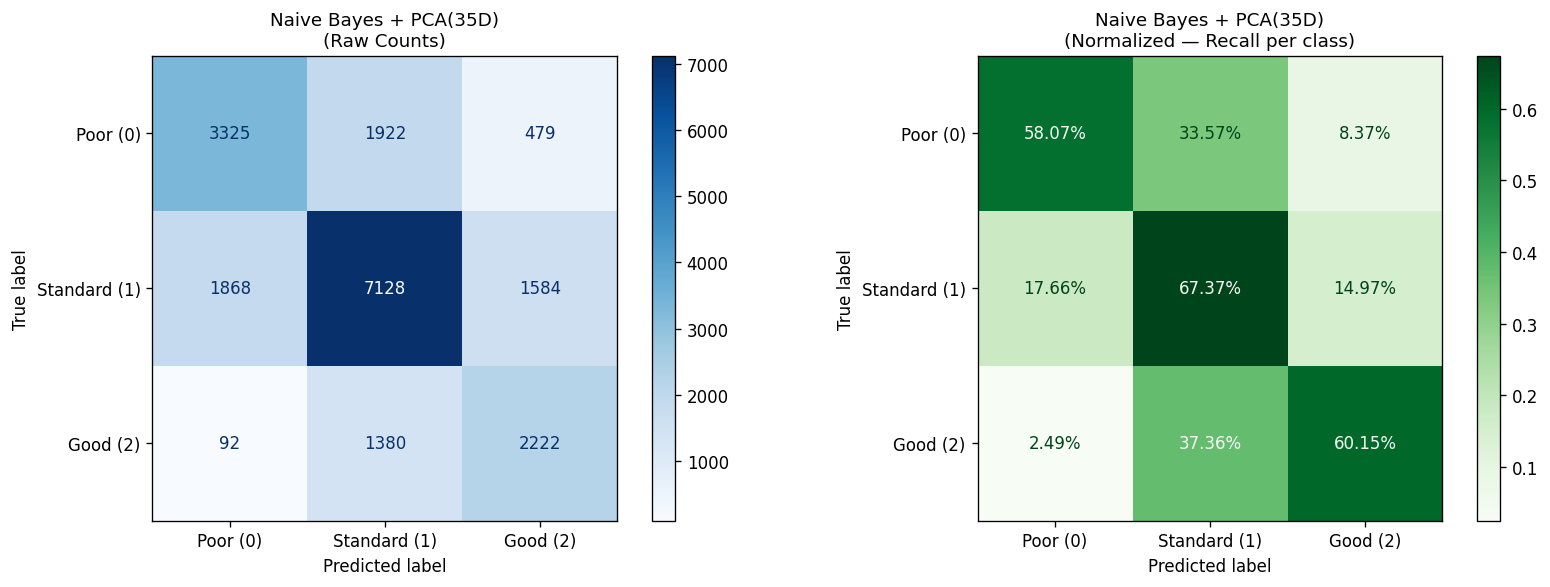


  Naive Bayes for origin data
              precision    recall  f1-score   support

    Poor (0)     0.5825    0.7428    0.6530      5726
Standard (1)     0.8081    0.4669    0.5919     10580
    Good (2)     0.4570    0.8148    0.5856      3694

    accuracy                         0.6101     20000
   macro avg     0.6159    0.6748    0.6101     20000
weighted avg     0.6787    0.6101    0.6082     20000

  Train Accuracy: 0.6070  |  Test Accuracy: 0.6101
  Train F1 (macro): 0.6044  |  Test F1 (macro): 0.6101
 Gap nhỏ: -0.0031 (model generalize tốt)


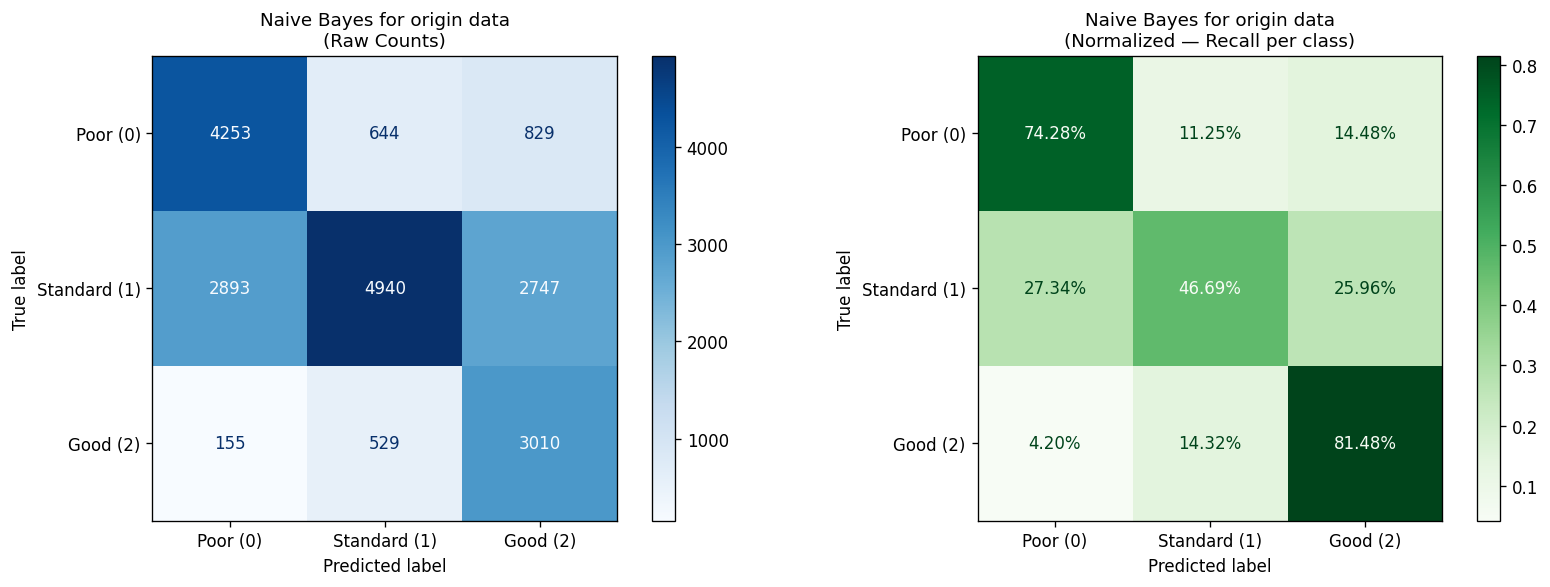

{'model': GaussianNB(),
 'name': 'Naive Bayes for origin data',
 'train_acc': 0.6070375,
 'test_acc': 0.61015,
 'train_f1': np.float64(0.6044294562790418),
 'test_f1': np.float64(0.6101398428373526),
 'y_pred': array([1, 2, 1, ..., 2, 2, 2])}

In [51]:
nb_model = GaussianNB()
evaluate_model(nb_model, X_train_pca, X_test_pca, y_train, y_test,
               "Naive Bayes + PCA(" + str(n_95) + "D)")
nb_model_old = GaussianNB() 
evaluate_model(nb_model_old, X_train_scaled, X_test_scaled, y_train, y_test, "Naive Bayes for origin data")

## 7.4. Logistic Regression + PCA
- Dùng `class_weight='balanced'` để xử lý class imbalance
- PCA giúp loại multicollinearity
- `max_iter=1000` để đảm bảo convergence



  Logistic Regression + PCA(35D)
              precision    recall  f1-score   support

    Poor (0)     0.5843    0.7087    0.6405      5726
Standard (1)     0.7922    0.5145    0.6238     10580
    Good (2)     0.4727    0.7913    0.5918      3694

    accuracy                         0.6212     20000
   macro avg     0.6164    0.6715    0.6187     20000
weighted avg     0.6736    0.6212    0.6227     20000

  Train Accuracy: 0.6103  |  Test Accuracy: 0.6212
  Train F1 (macro): 0.6060  |  Test F1 (macro): 0.6187
  Underfit: Test > Train (unusual)


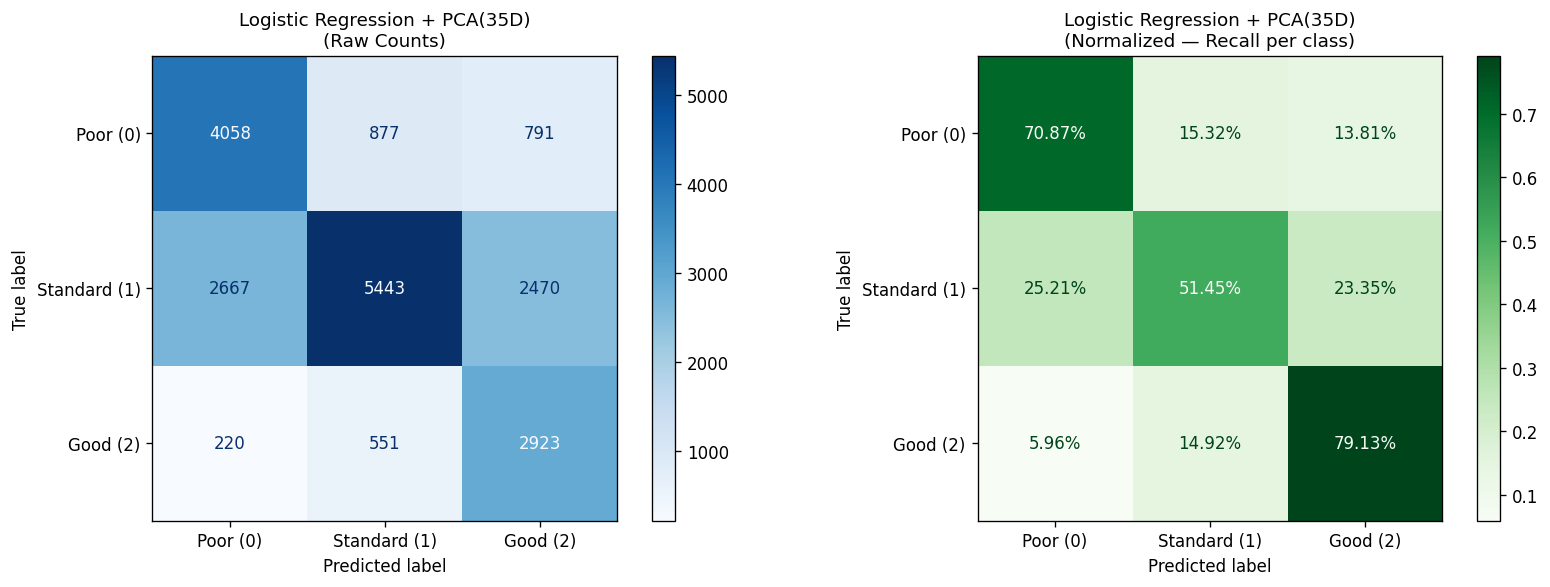


  Logistic Regression for origin data
              precision    recall  f1-score   support

    Poor (0)     0.5936    0.7042    0.6442      5726
Standard (1)     0.8097    0.5643    0.6651     10580
    Good (2)     0.5174    0.8173    0.6336      3694

    accuracy                         0.6511     20000
   macro avg     0.6402    0.6952    0.6476     20000
weighted avg     0.6939    0.6511    0.6533     20000

  Train Accuracy: 0.6445  |  Test Accuracy: 0.6511
  Train F1 (macro): 0.6387  |  Test F1 (macro): 0.6476
 Gap nhỏ: -0.0065 (model generalize tốt)


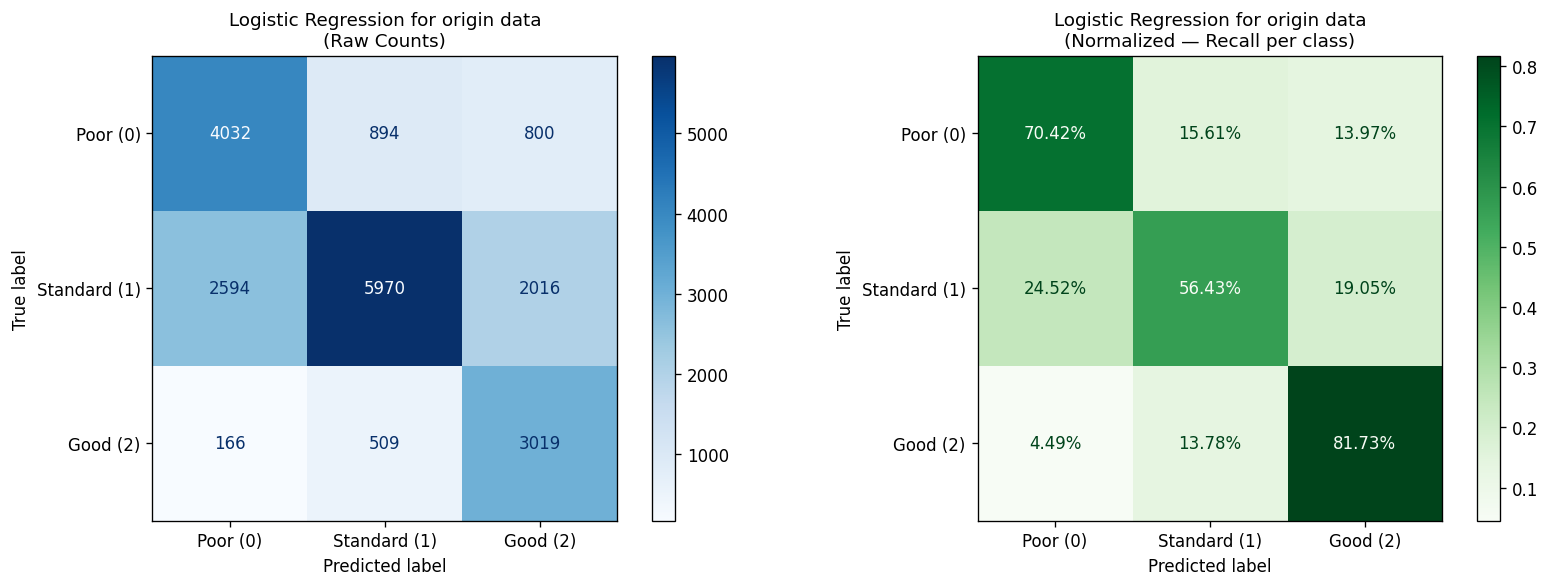

{'model': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
 'name': 'Logistic Regression for origin data',
 'train_acc': 0.6445375,
 'test_acc': 0.65105,
 'train_f1': np.float64(0.6387493408428231),
 'test_f1': np.float64(0.647635643802295),
 'y_pred': array([1, 1, 1, ..., 2, 2, 2])}

In [53]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  
    solver='lbfgs',
    random_state=42
)
evaluate_model(lr_model, X_train_pca, X_test_pca, y_train, y_test,
               "Logistic Regression + PCA(" + str(n_95) + "D)")


lr_model_old = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  
    solver='lbfgs',
    random_state=42
)
evaluate_model(lr_model_old, X_train_scaled, X_test_scaled, y_train, y_test,
               "Logistic Regression for origin data")

## 7.5. MLP (Neural Network) + PCA
- MLP đủ mạnh để tự học feature representations
- PCA giúp tăng tốc training
- `early_stopping=True` chống overfit



  MLP + PCA(35D)
              precision    recall  f1-score   support

    Poor (0)     0.5953    0.6537    0.6231      5726
Standard (1)     0.6941    0.6705    0.6821     10580
    Good (2)     0.5276    0.4986    0.5127      3694

    accuracy                         0.6340     20000
   macro avg     0.6057    0.6076    0.6060     20000
weighted avg     0.6350    0.6340    0.6339     20000

  Train Accuracy: 0.7632  |  Test Accuracy: 0.6340
  Train F1 (macro): 0.7459  |  Test F1 (macro): 0.6060
  Overfit gap: 0.1292 (Train >> Test)


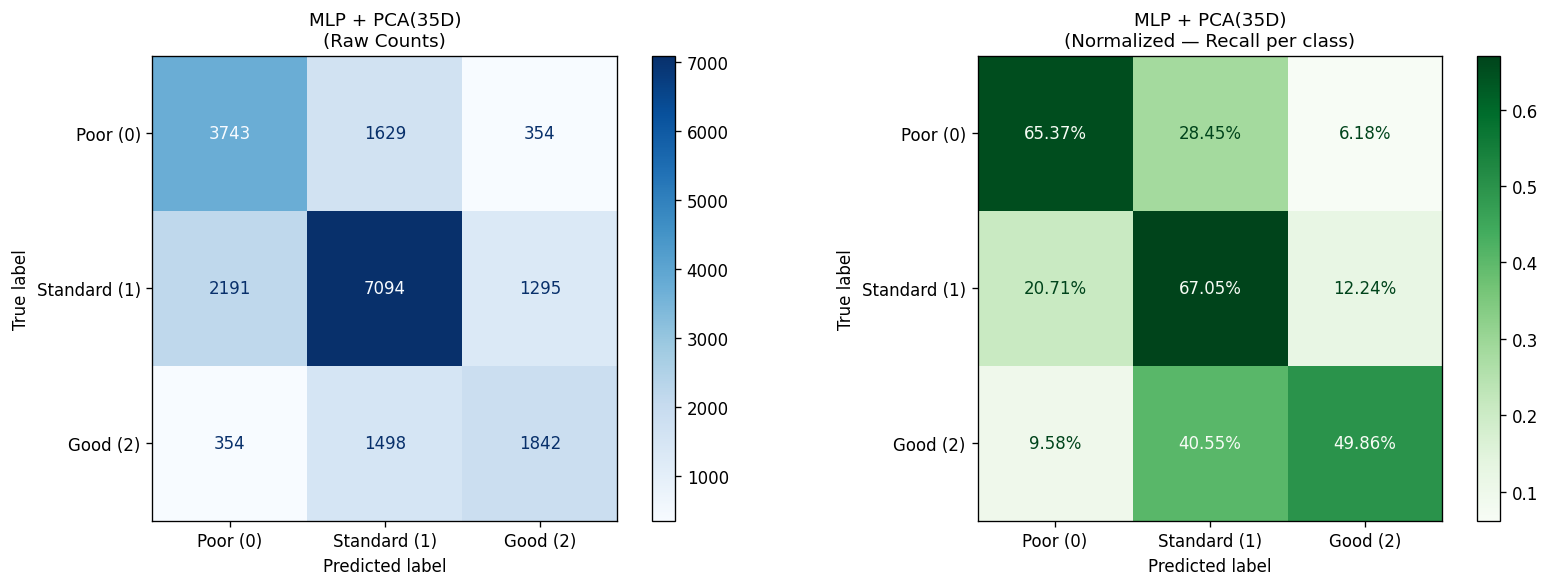


  MLP for origin data
              precision    recall  f1-score   support

    Poor (0)     0.6142    0.6677    0.6398      5726
Standard (1)     0.7005    0.7056    0.7030     10580
    Good (2)     0.5675    0.4792    0.5196      3694

    accuracy                         0.6529     20000
   macro avg     0.6274    0.6175    0.6208     20000
weighted avg     0.6512    0.6529    0.6510     20000

  Train Accuracy: 0.7798  |  Test Accuracy: 0.6529
  Train F1 (macro): 0.7622  |  Test F1 (macro): 0.6208
  Overfit gap: 0.1269 (Train >> Test)


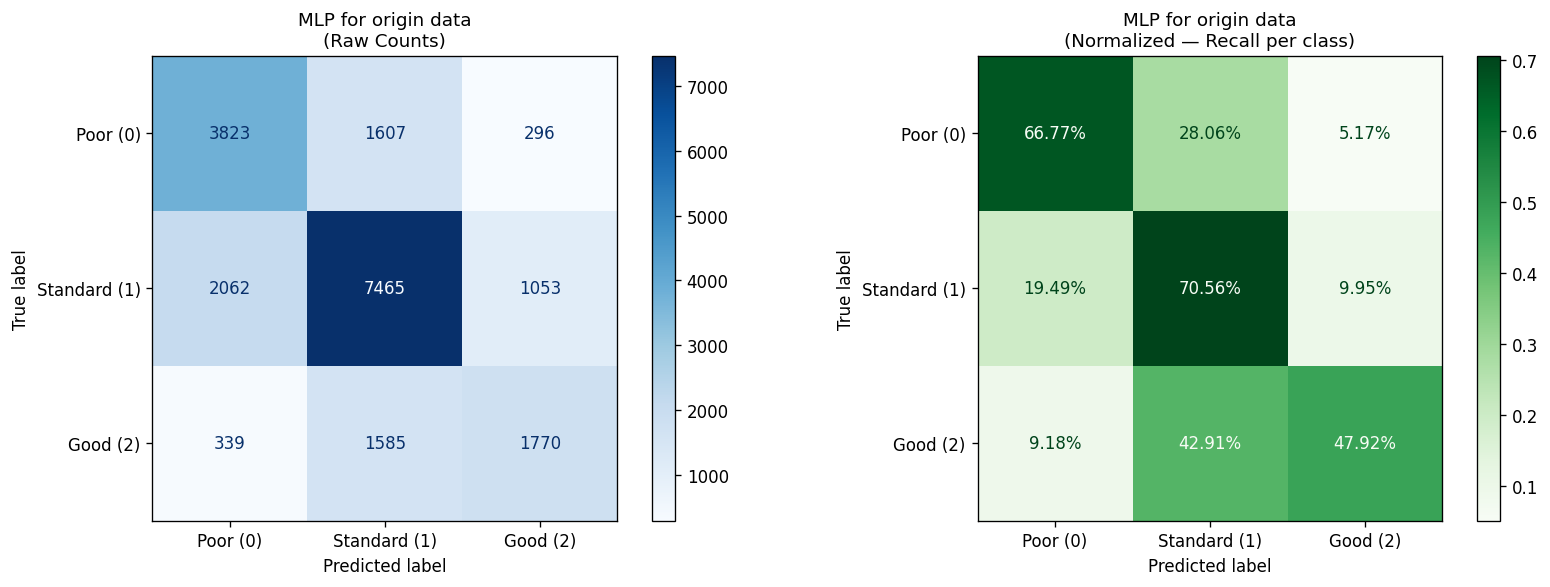

{'model': MLPClassifier(alpha=0.01, batch_size=256, early_stopping=True,
               hidden_layer_sizes=(64, 32), learning_rate='adaptive',
               n_iter_no_change=20, random_state=42),
 'name': 'MLP for origin data',
 'train_acc': 0.779775,
 'test_acc': 0.6529,
 'train_f1': np.float64(0.7622183575444383),
 'test_f1': np.float64(0.6208152817297914),
 'y_pred': array([1, 1, 1, ..., 2, 2, 2])}

In [54]:

mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),  
    activation='relu',           
    solver='adam',               
    alpha=0.01,            
    batch_size=256,             
    learning_rate='adaptive',     
    max_iter=200,
    early_stopping=True,         
    validation_fraction=0.1,    
    n_iter_no_change=20,         
    random_state=42,
    verbose=False, 
)
evaluate_model(mlp_model, X_train_pca, X_test_pca, y_train, y_test,
               "MLP + PCA(" + str(n_95) + "D)")
               
mlp_model_old = MLPClassifier(
    hidden_layer_sizes=(64, 32),  
    activation='relu',           
    solver='adam',               
    alpha=0.01,            
    batch_size=256,             
    learning_rate='adaptive',     
    max_iter=200,
    early_stopping=True,         
    validation_fraction=0.1,    
    n_iter_no_change=20,         
    random_state=42,
    verbose=False, 
)
evaluate_model(mlp_model_old, X_train_scaled, X_test_scaled, y_train, y_test,
               "MLP for origin data")


## 7.6. KNN + PCA (20D)
- KNN bị **curse of dimensionality** → giảm chiều BẮT BUỘC
- 20D là tradeoff tốt giữa information retention và distance computation
- `weights='distance'` để gần hơn thì quan trọng hơn



  KNN + PCA(20D)
              precision    recall  f1-score   support

    Poor (0)     0.6069    0.5816    0.5940      5726
Standard (1)     0.6517    0.7163    0.6825     10580
    Good (2)     0.5310    0.4147    0.4657      3694

    accuracy                         0.6220     20000
   macro avg     0.5965    0.5708    0.5807     20000
weighted avg     0.6166    0.6220    0.6171     20000

  Train Accuracy: 0.6951  |  Test Accuracy: 0.6220
  Train F1 (macro): 0.6589  |  Test F1 (macro): 0.5807
  Overfit gap: 0.0731 (Train >> Test)


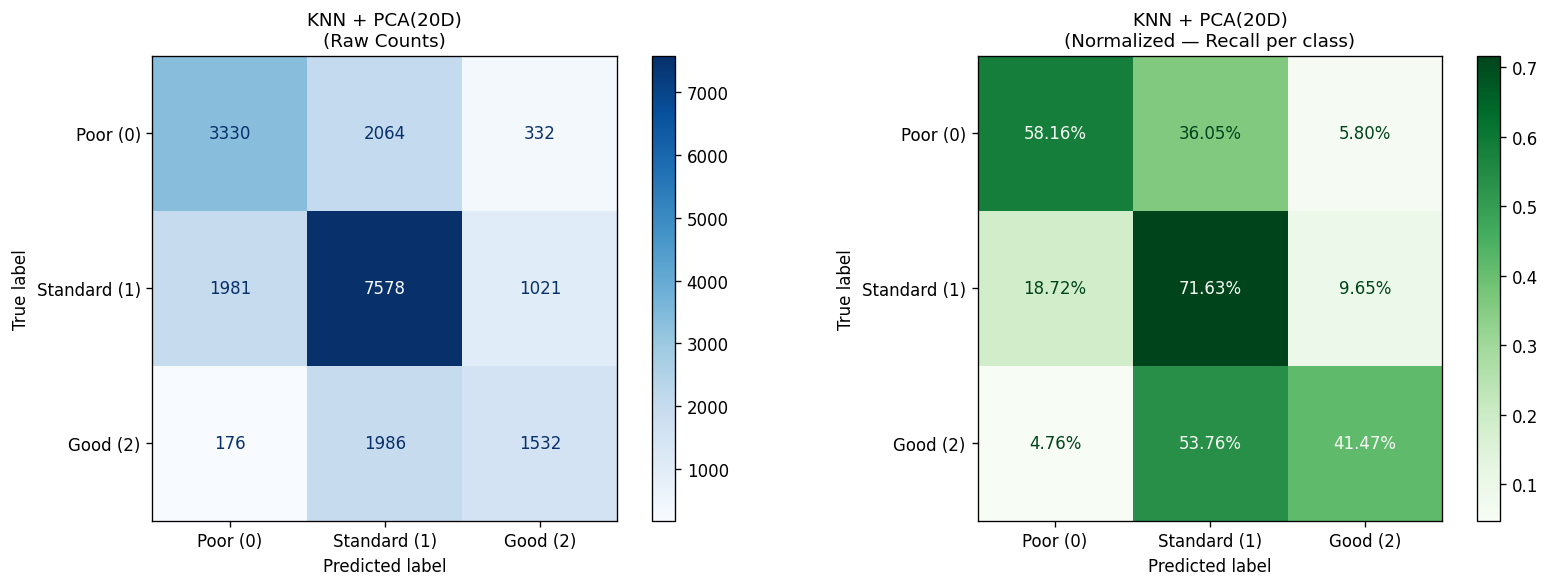


  KNN for origin data
              precision    recall  f1-score   support

    Poor (0)     0.6250    0.5536    0.5871      5726
Standard (1)     0.6459    0.7510    0.6945     10580
    Good (2)     0.5308    0.3774    0.4411      3694

    accuracy                         0.6255     20000
   macro avg     0.6006    0.5607    0.5743     20000
weighted avg     0.6187    0.6255    0.6170     20000

  Train Accuracy: 0.7270  |  Test Accuracy: 0.6255
  Train F1 (macro): 0.6941  |  Test F1 (macro): 0.5743
  Overfit gap: 0.1015 (Train >> Test)


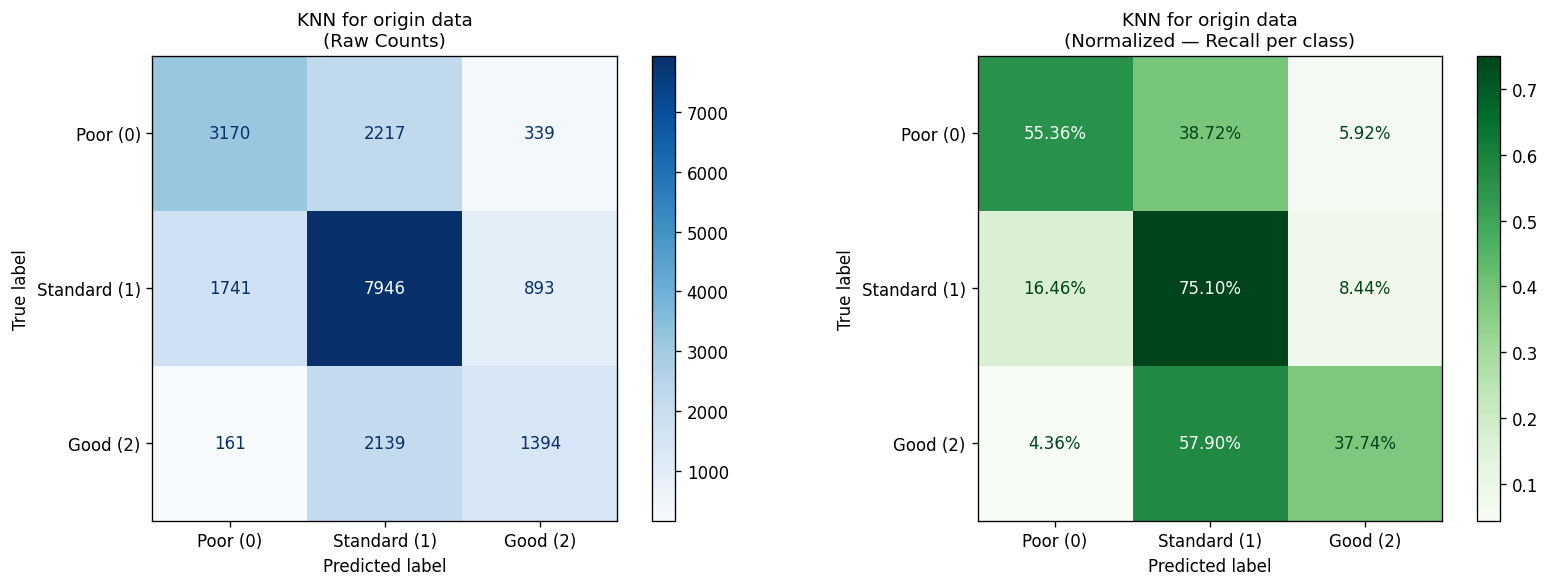

{'model': KNeighborsClassifier(metric='euclidean', n_jobs=-1, n_neighbors=31),
 'name': 'KNN for origin data',
 'train_acc': 0.7269625,
 'test_acc': 0.6255,
 'train_f1': np.float64(0.6941061703262141),
 'test_f1': np.float64(0.5742682393522235),
 'y_pred': array([1, 1, 1, ..., 2, 1, 1])}

In [55]:
k = 31  

knn_model = KNeighborsClassifier(
    n_neighbors=k,
    metric='euclidean',
    weights='uniform' , 
    n_jobs=-1
)
evaluate_model(knn_model, X_train_pca_knn, X_test_pca_knn, y_train, y_test,
               "KNN + PCA(20D)")


knn_model_old = KNeighborsClassifier(
    n_neighbors=k,
    metric='euclidean',
    weights='uniform' , 
    n_jobs=-1
)
evaluate_model(knn_model_old, X_train_scaled, X_test_scaled, y_train, y_test,
               "KNN for origin data")



 Vấn đề chung: Class Good bị predict kém nhất
Cả 2 models đều có F1 cho class Good rất thấp (~0.48-0.49) so với Standard (~0.68).

Lý do:

Class Imbalance: Good chỉ có 3694 mẫu (18.5%) so với Standard 10580 (52.9%). Model bị bias về predict Standard vì đó là class phổ biến nhất → recall cho Good chỉ ~0.44 (hơn một nửa mẫu Good bị phân loại sai).

Feature Overlap: Nhìn từ biểu đồ feature-by-class (Cell 40), các features phân phối của Standard và Good chồng lấn nhiều → khó phân biệt 2 class này.

Multi-modal data: Các features thu nhập (Monthly_Inhand_Salary, etc.) có phân phối nhiều đỉnh → GaussianNB sẽ bị ảnh hưởng nặng, LR/MLP cũng bị ảnh hưởng mức độ vừa phải.

## 7.X.  — Kiểm tra Overfitting

Learning curve cho thấy:
- **Overfitting**: training score cao, validation score thấp, gap không giảm khi tăng data
- **Underfitting**: cả training và validation score đều thấp
- **Good fit**: 2 đường hội tụ khi tăng data


In [ ]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, X, y, name, cv=5, scoring='f1_macro',
                        train_sizes=np.linspace(0.1, 1.0, 8)):
    train_sizes_abs, train_scores, val_scores = learning_curve(
        estimator, X, y, 
        train_sizes=train_sizes,
        cv=cv, 
        scoring=scoring,
        n_jobs=-1,
        random_state=42
    )
    
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    ax.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color='steelblue')
    ax.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color='#e74c3c')
    
    ax.plot(train_sizes_abs, train_mean, 'o-', color='steelblue', 
            label=f'Training ({train_mean[-1]:.3f})')
    ax.plot(train_sizes_abs, val_mean, 'o-', color='#e74c3c', 
            label=f'Validation ({val_mean[-1]:.3f})')
    
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel(f'{scoring}')
    ax.set_title(f'Learning Curve — {name}', fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    
    # Annotate overfit gap
    gap = train_mean[-1] - val_mean[-1]
    if gap > 0.05:
        ax.annotate(f'⚠️ Overfit gap: {gap:.3f}', 
                   xy=(0.5, 0.02), xycoords='axes fraction',
                   fontsize=11, color='red', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return train_mean[-1], val_mean[-1]


  LEARNING CURVE ANALYSIS

--- MLP ---


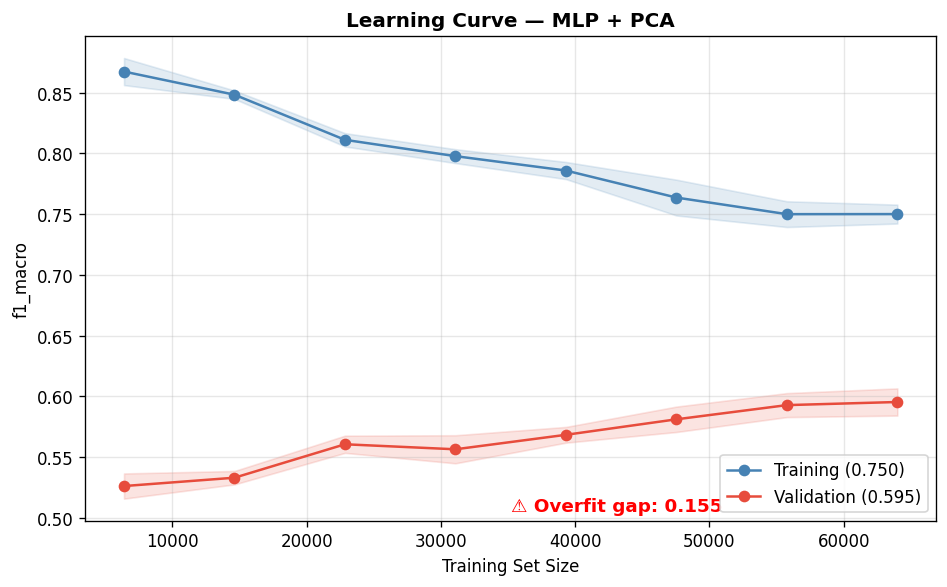


--- KNN ---


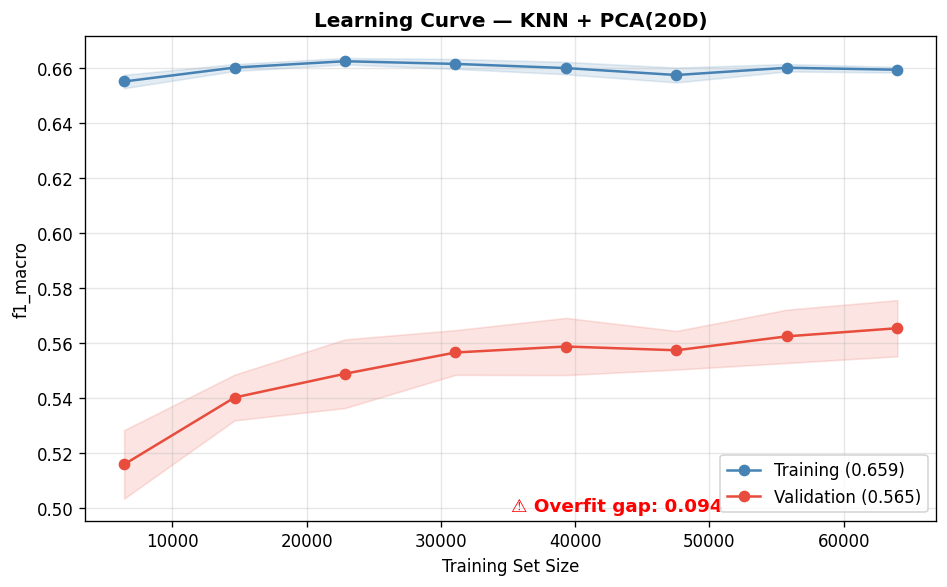


--- Naive Bayes ---


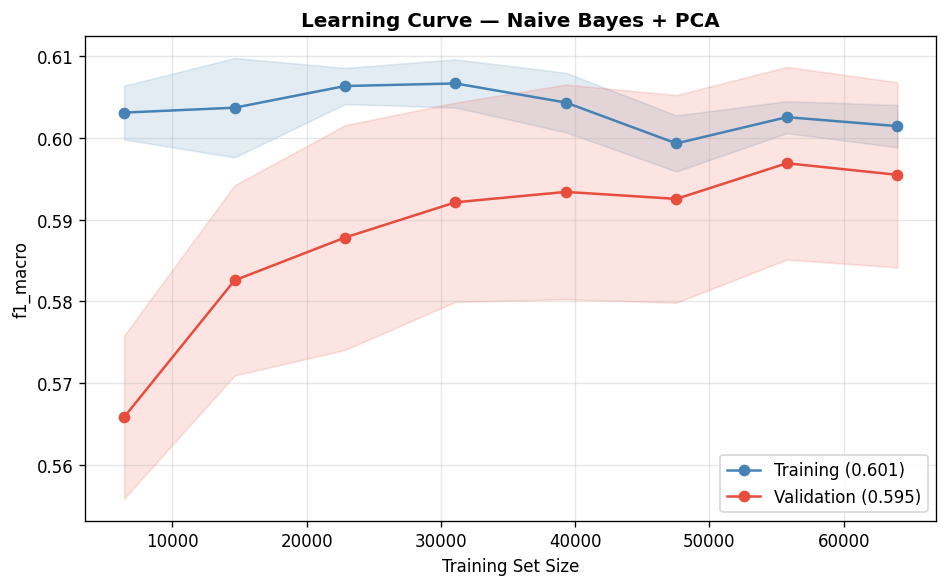


--- Logistic Regression ---


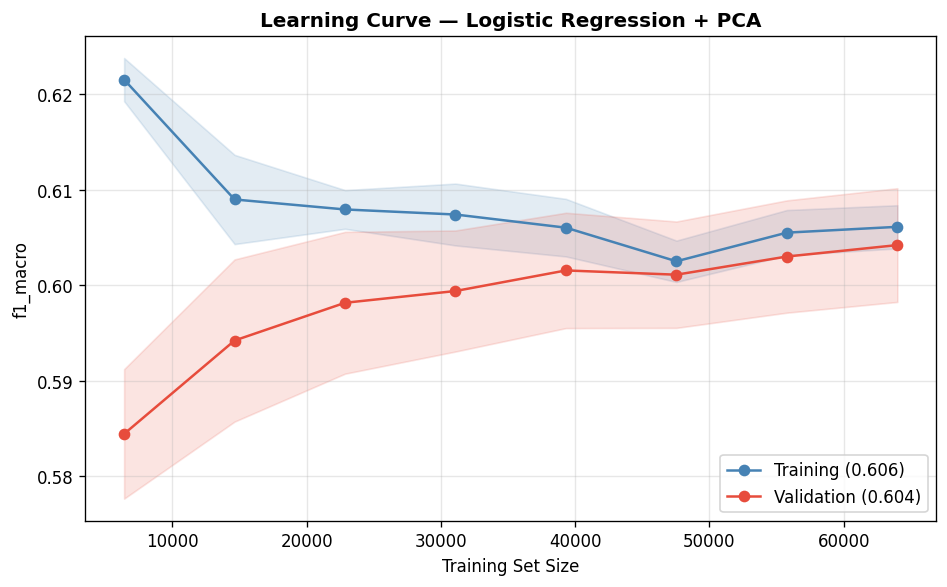

(np.float64(0.60611287946078), np.float64(0.6042000848269649))

In [49]:

# MLP
print("\n--- MLP ---")
plot_learning_curve(
    MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', 
                  solver='adam', alpha=0.01, batch_size=256,
                  learning_rate='adaptive', max_iter=200,
                  early_stopping=True, validation_fraction=0.1,
                  n_iter_no_change=15, random_state=42, verbose=False),
    X_train_pca, y_train, "MLP + PCA"
)

# KNN
print("\n--- KNN ---")
plot_learning_curve(
    KNeighborsClassifier(n_neighbors=31, metric='euclidean', 
                         weights='uniform', n_jobs=-1),
    X_train_pca_knn, y_train, "KNN + PCA(20D)"
)


print("\n--- Naive Bayes ---")
plot_learning_curve(
    GaussianNB(),
    X_train_pca, y_train, "Naive Bayes + PCA"
)


print("\n--- Logistic Regression ---")
plot_learning_curve(
    LogisticRegression(max_iter=1000, class_weight='balanced', 
                       solver='lbfgs', random_state=42),
    X_train_pca, y_train, "Logistic Regression + PCA"
)
